# Clustering

In [109]:
import matplotlib as plt
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import gridspec
from matplotlib.lines import Line2D
import pandas as pd
import numpy as np

Brown (2019): https://github.com/IrinaStatsLab/Awesome-CGM/wiki/Brown-(2019)

Quick statistics:

* 168 patients
* no. of recorded events by patient vary from 36,220 to 57,756
* the date range across all patients is from 4.08.2016 to 25.03.2019
* continuous recorded periods for each patient vary from 183 to 204 days with one exeption where one patient had 846 days worth of recorded events

In [110]:
dclp3 = pd.read_csv("C:/Users/meril/Desktop/Projekt_ML/DCLP3/Data Files/cgm.txt", sep="|")

# Clustering -- can the patients in the data set be clustered into certain groups?

In [157]:
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr
from tslearn.metrics import dtw, soft_dtw
from fastdtw import fastdtw
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

In [158]:
dclp3

,PtID,Period,DataDtTm,CGM,date,time,hour,minute,TimeIndex,delta_min,time_period,CGM_mmol,in_range,CGM_mmol_diff,rolling_mean_mmol,rolling_std_mmol,delta_from_mean,CGM_category,weekday_name
0,1,1. Baseline,2017-12-11 23:59:25,172,2017-12-11,23:59:25,23,59,1439,NaN,21:00–00:00,9.555556,True,NaN,9.555556,NaN,0.000000,in_range,Monday
1,1,1. Baseline,2017-12-12 00:04:24,170,2017-12-12,00:04:24,0,4,4,4.983333,00:00–03:00,9.444444,True,-0.111111,9.500000,0.078567,-0.055556,in_range,Tuesday
2,1,1. Baseline,2017-12-12 00:09:24,167,2017-12-12,00:09:24,0,9,9,5.000000,00:00–03:00,9.277778,True,-0.166667,9.425926,0.139812,-0.148148,in_range,Tuesday
3,1,1. Baseline,2017-12-12 00:14:25,163,2017-12-12,00:14:25,0,14,14,5.016667,00:00–03:00,9.055556,True,-0.222222,9.333333,0.217543,-0.277778,in_range,Tuesday
4,1,1. Baseline,2017-12-12 00:19:25,160,2017-12-12,00:19:25,0,19,19,5.000000,00:00–03:00,8.888889,True,-0.166667,9.166667,0.244276,-0.277778,in_range,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4292120,171,2. Post Randomization,2018-10-24 08:50:04,174,2018-10-24,08:50:04,8,50,530,5.000000,03:00–09:00,9.666667,True,0.333333,9.347222,0.232958,0.319444,in_range,Wednesday
4292121,171,2. Post Randomization,2018-10-24 08:55:04,192,2018-10-24,08:55:04,8,55,535,5.000000,03:00–09:00,10.666667,False,1.000000,9.736111,0.643702,0.930556,hyperglycemia,Wednesday
4292122,171,2. Post Randomization,2018-10-24 09:00:04,189,2018-10-24,09:00:04,9,0,540,5.000000,09:00–12:00,10.500000,False,-0.166667,10.041667,0.643702,0.458333,hyperglycemia,Wednesday
4292123,171,2. Post Randomization,2018-10-24 09:05:04,183,2018-10-24,09:05:04,9,5,545,5.000000,09:00–12:00,10.166667,False,-0.333333,10.250000,0.440959,-0.083333,hyperglycemia,Wednesday


## Experiment 1

In [159]:
# 1) Functions for data preparation and feature calculation

def prepare_bins(df, bin_minutes=30):
    df2 = df.copy()
    minute_of_day = df2['DataDtTm'].dt.hour * 60 + df2['DataDtTm'].dt.minute
    df2['bin'] = (minute_of_day // bin_minutes).astype(int)
    n_bins = (24*60) // bin_minutes
    df2['zone'] = np.select(
        [df2['CGM_mmol'] < 4,
         df2['CGM_mmol'].between(4, 10),
         df2['CGM_mmol'] > 10],
        ['TBR','TIR','TAR'],
        default='missing'
    )
    return df2, n_bins

def build_profile_features(df_binned, n_bins):
    # counts per PtID x bin x zone
    counts = df_binned.groupby(['PtID','bin'])['zone'].value_counts().unstack(fill_value=0)
    counts = counts.reindex(columns=['TBR','TIR','TAR'], fill_value=0)
    total_per_bin = counts.sum(axis=1).replace(0, np.nan)
    props = counts.div(total_per_bin, axis=0).fillna(0)
    # reshape to PtID x (n_bins * 3)
    profiles = {}
    for pt, grp in props.groupby(level=0):
        arr = grp.droplevel(0).reindex(range(n_bins), fill_value=0).values  # shape n_bins x 3
        profiles[pt] = arr.flatten()  # length n_bins*3
    profiles_df = pd.DataFrame.from_dict(profiles, orient='index')
    profiles_df.index.name = 'PtID'
    profiles_df.columns = [f'bin{int(i//3)}_{["TBR","TIR","TAR"][i%3]}' for i in range(n_bins*3)]
    # overall TIR/TBR/TAR
    overall = df_binned.groupby('PtID')['CGM_mmol'].apply(lambda s: pd.Series({
        'TIR_pct': (s.between(4,10)).mean()*100,
        'TBR_pct': (s < 4).mean()*100,
        'TAR_pct': (s > 10).mean()*100
    })).unstack()
    # night hypo freq (00-06)
    night_mask = df_binned['DataDtTm'].dt.hour.isin(range(0,6))
    night_hypo = df_binned[night_mask].groupby('PtID')['CGM_mmol'].apply(lambda s: (s<4).mean()*100).rename('night_hypo_pct')
    # dawn phenomenon: mean 04-08 vs 00-03 (mmol)
    mean_before = df_binned[df_binned['DataDtTm'].dt.hour.isin([0,1,2,3])].groupby('PtID')['CGM_mmol'].mean().rename('mean_00_03')
    mean_after  = df_binned[df_binned['DataDtTm'].dt.hour.isin([4,5,6,7,8])].groupby('PtID')['CGM_mmol'].mean().rename('mean_04_08')
    dawn_df = pd.concat([mean_before, mean_after], axis=1).fillna(0)
    dawn_df['dawn_diff'] = dawn_df['mean_04_08'] - dawn_df['mean_00_03']
    dawn_df['dawn_flag'] = (dawn_df['dawn_diff'] > 1.1).astype(int)
    # evening rise: mean 17-21 vs 12-16
    mean_mid  = df_binned[df_binned['DataDtTm'].dt.hour.isin([12,13,14,15,16])].groupby('PtID')['CGM_mmol'].mean().rename('mean_12_16')
    mean_even = df_binned[df_binned['DataDtTm'].dt.hour.isin([17,18,19,20,21])].groupby('PtID')['CGM_mmol'].mean().rename('mean_17_21')
    evening_df = pd.concat([mean_mid, mean_even], axis=1).fillna(0)
    evening_df['evening_diff'] = evening_df['mean_17_21'] - evening_df['mean_12_16']
    evening_df['evening_flag'] = (evening_df['evening_diff'] > 1.1).astype(int)
    # Merge features
    meta = overall.join(night_hypo, how='left').join(dawn_df[['dawn_diff','dawn_flag']], how='left').join(evening_df[['evening_diff','evening_flag']], how='left')
    meta = meta.fillna(0)
    features = profiles_df.join(meta, how='left').fillna(0)
    return features, n_bins


In [160]:
# 2) Clustering wrapper: differente distance measures and methods

def cluster_and_evaluate(X, method_name='euclidean', n_clusters=4, random_state=42):
    scaler = StandardScaler()
    Xs = scaler.fit_transform(X)
    if method_name == 'euclidean':
        km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
        labels = km.fit_predict(Xs)
        score = silhouette_score(Xs, labels)
        model = km
    elif method_name == 'ward':
        agg = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
        labels = agg.fit_predict(Xs)
        score = silhouette_score(Xs, labels)
        model = agg
    elif method_name == 'corr':  # 1 - Pearson corr as distance
        D = 1 - np.corrcoef(X.T)  # caution: corr of features - we want correlation of rows => do pairwise below
        # Instead compute pairwise 1-pearson between rows
        dist = squareform(pdist(Xs, metric=lambda u,v: 1 - np.corrcoef(u, v)[0,1]))
        agg = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='average')
        labels = agg.fit_predict(dist)
        score = silhouette_score(dist, labels, metric='precomputed')
        model = agg
    else:
        raise ValueError("Unknown method")
    return labels, score, model, Xs

In [161]:
# 3) Visualization: Cluster average profiles (TIR/TBR/TAR)

def plot_cluster_profiles(features, n_bins, bin_minutes, labels, show_TIR=True):
    pts = features.index.values
    n_clusters = len(np.unique(labels))
    fig, axes = plt.subplots(1, n_clusters, figsize=(4*n_clusters, 4), sharey=True)
    if n_clusters == 1:
        axes = [axes]
    bin_hours = np.arange(n_bins) * (bin_minutes/60)
    for c in range(n_clusters):
        ax = axes[c]
        members = features.index[labels == c]
        if len(members)==0:
            continue
        # reconstruct per-bin TIR/TBR/TAR means
        cols_tbr = [col for col in features.columns if col.startswith('bin') and col.endswith('_TBR')]
        cols_tir = [col for col in features.columns if col.startswith('bin') and col.endswith('_TIR')]
        cols_tar = [col for col in features.columns if col.startswith('bin') and col.endswith('_TAR')]
        mean_tbr = features.loc[members, cols_tbr].mean(axis=0).values
        mean_tir = features.loc[members, cols_tir].mean(axis=0).values
        mean_tar = features.loc[members, cols_tar].mean(axis=0).values
        ax.plot(bin_hours, mean_tir, label='TIR', linewidth=2, color = "forestgreen")
        ax.plot(bin_hours, mean_tar, label='TAR', linewidth=2, color = "orange")
        ax.plot(bin_hours, mean_tbr, label='TBR', linewidth=2, color = "firebrick")
        ax.set_title(f'Cluster {c} (n={len(members)})')
        ax.set_xlabel('Hour of day')
        if c==0:
            ax.set_ylabel('Proportion')
        ax.grid(alpha=0.3)
        ax.set_xlim(0,24)
        ax.legend()
    plt.suptitle(f'Profile of patients — bin {bin_minutes} min')
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()


In [162]:
# 4) Main: iterating over bin_sizes and methods
def run_clustering_experiments(df, bin_sizes = [15, 20,30,60], cluster_counts=[2,3,4,5], methods=['euclidean','corr']):
    results = {}
    for bin_minutes in bin_sizes:
        df_binned, n_bins = prepare_bins(df, bin_minutes=bin_minutes)
        features, n_bins = build_profile_features(df_binned, n_bins)
        for method in methods:
            for k in cluster_counts:
                labels, score, model, Xs = cluster_and_evaluate(features, method_name=method, n_clusters=k)
                key = (bin_minutes, method, k)
                results[key] = {
                    'labels': labels,
                    'score': score,
                    'model': model,
                    'features': features,
                    'n_bins': n_bins
                }
                print(f'bin={bin_minutes}min method={method} k={k} silhouette={score:.3f}')
                plot_cluster_profiles(features, n_bins, bin_minutes, labels)
    return results

bin=15min method=euclidean k=2 silhouette=0.275


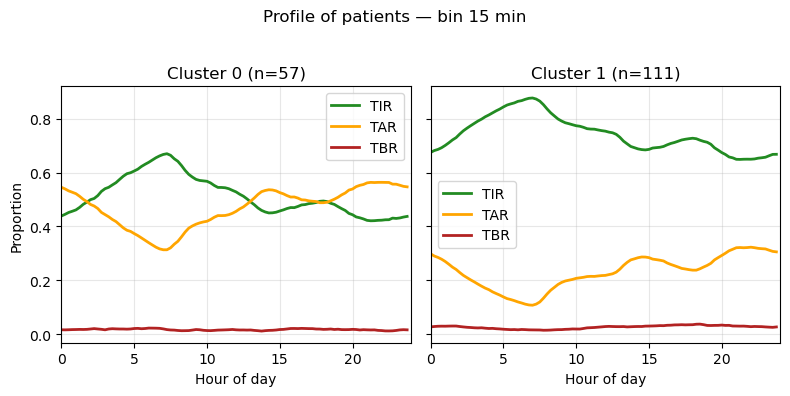

bin=15min method=euclidean k=3 silhouette=0.212


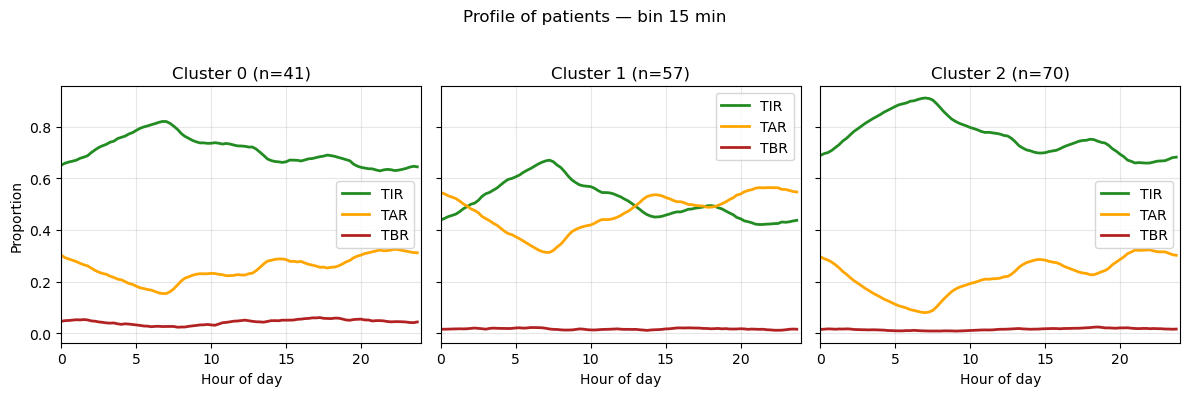

bin=15min method=euclidean k=4 silhouette=0.172


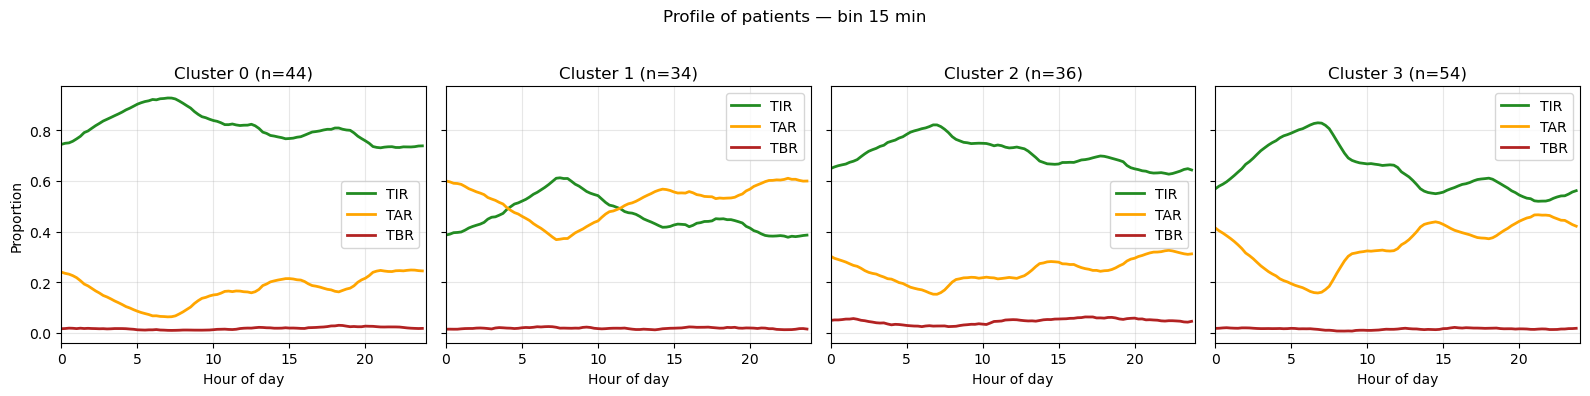

bin=15min method=euclidean k=5 silhouette=0.162


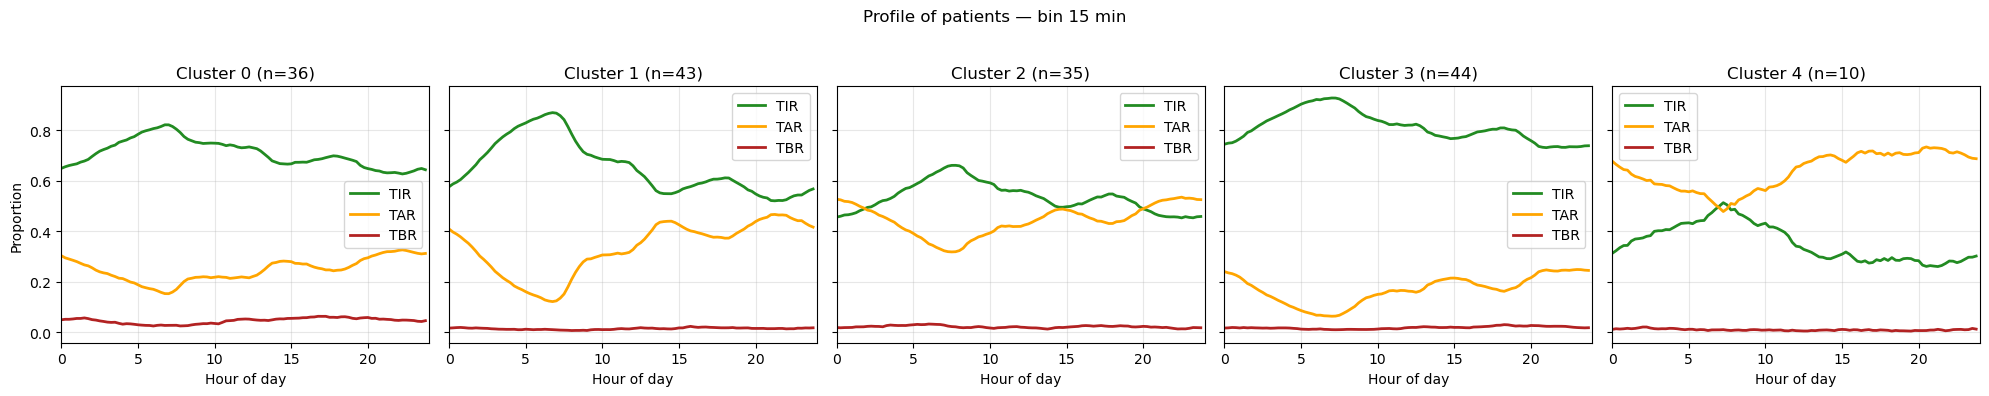

bin=15min method=corr k=2 silhouette=0.399


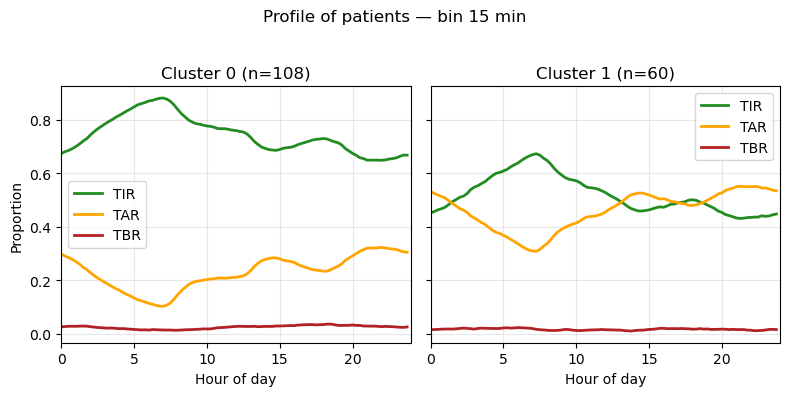

bin=15min method=corr k=3 silhouette=0.354


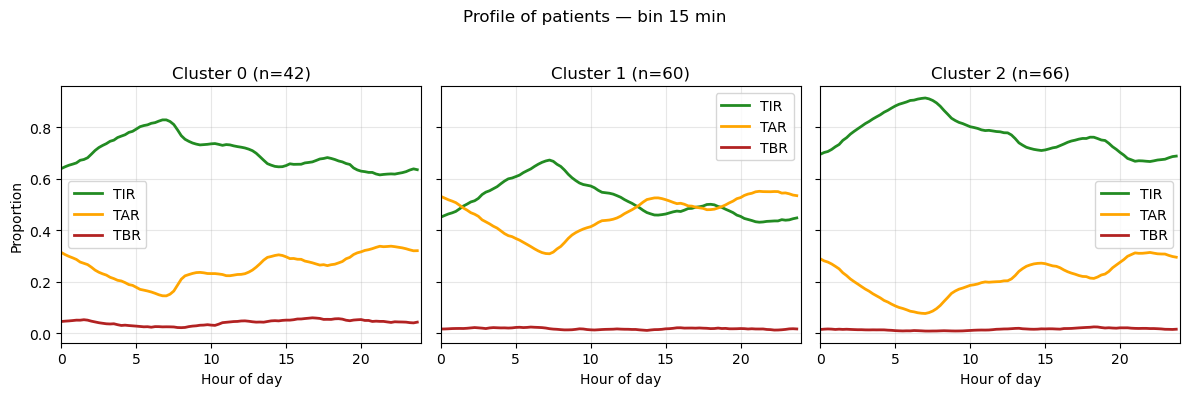

bin=15min method=corr k=4 silhouette=0.322


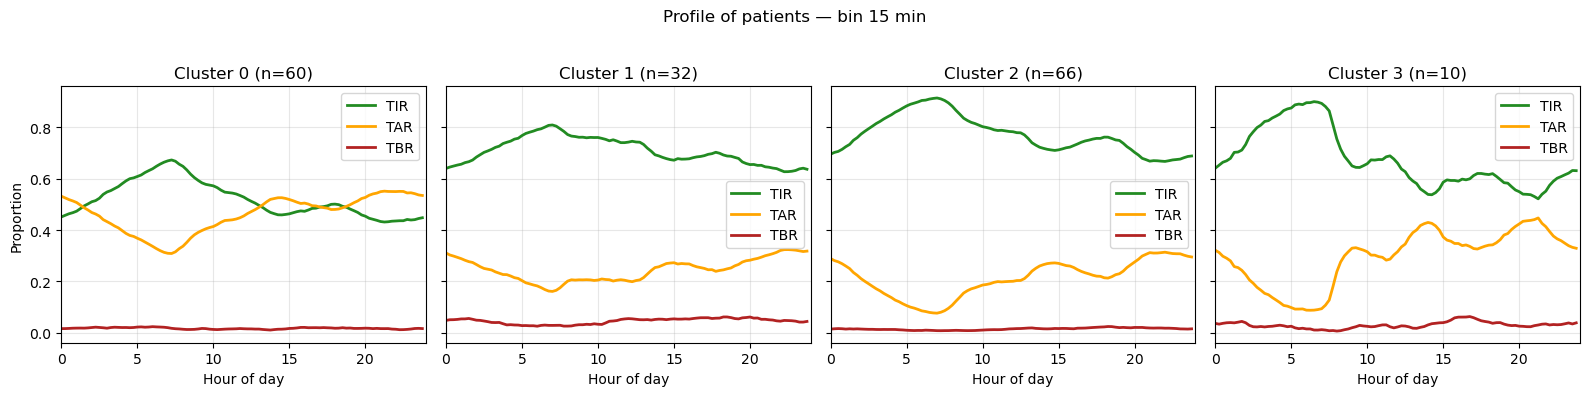

bin=15min method=corr k=5 silhouette=0.276


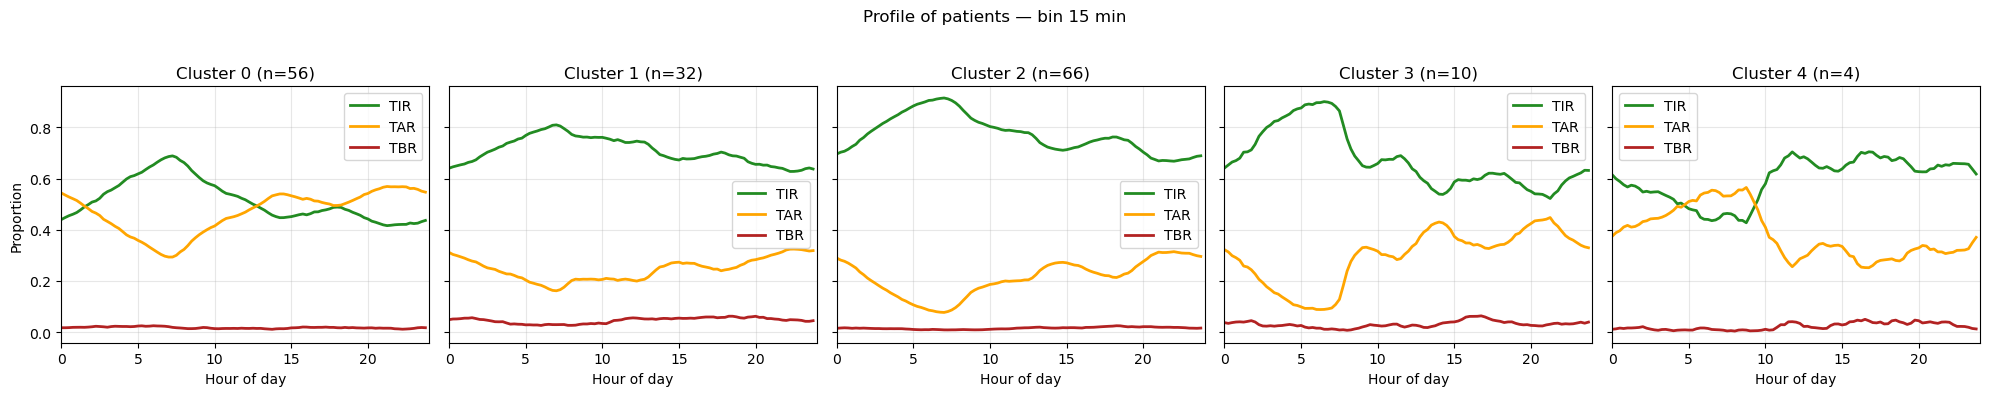

bin=15min method=ward k=2 silhouette=0.270


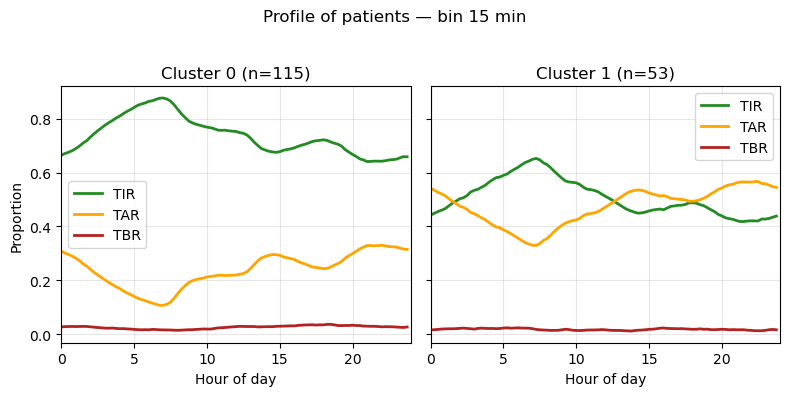

bin=15min method=ward k=3 silhouette=0.187


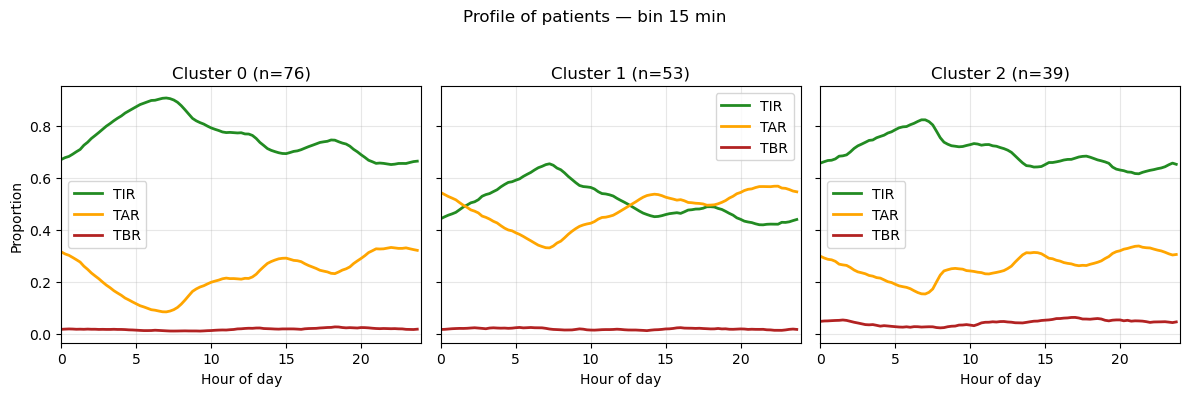

bin=15min method=ward k=4 silhouette=0.131


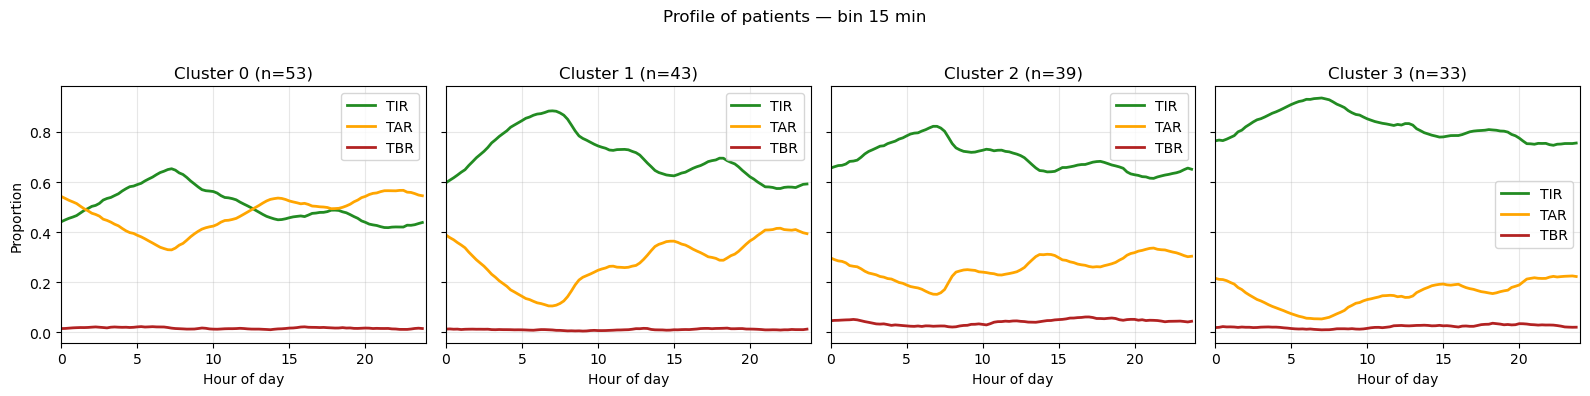

bin=15min method=ward k=5 silhouette=0.129


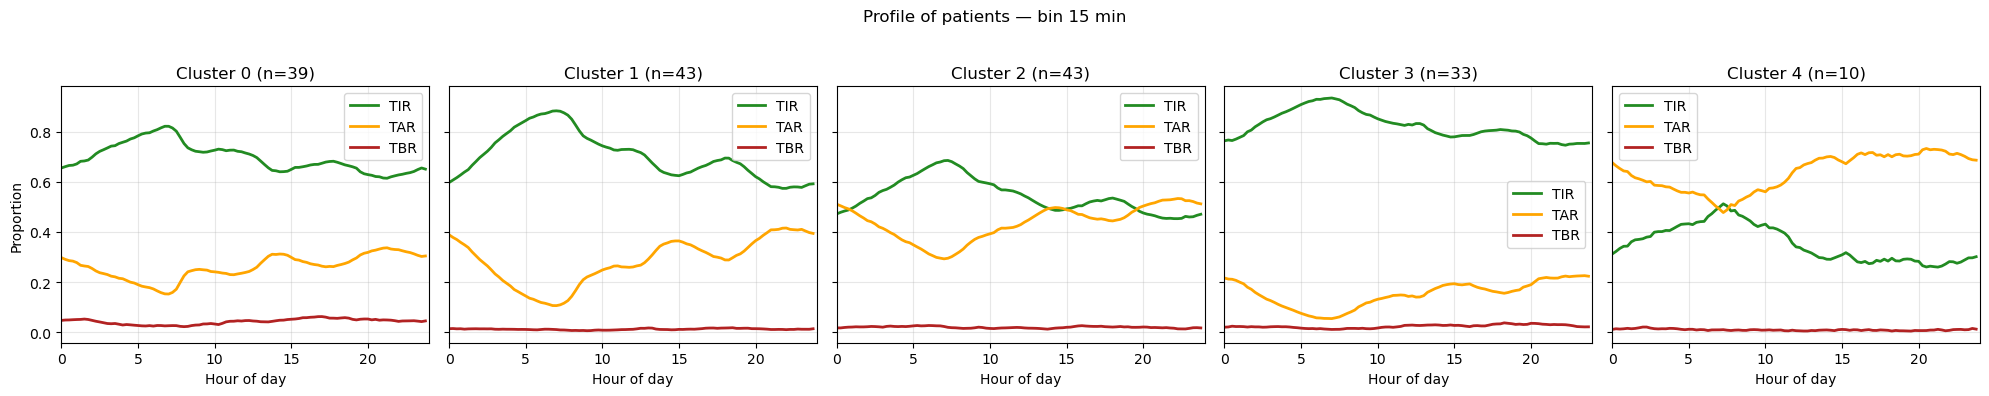

bin=20min method=euclidean k=2 silhouette=0.275


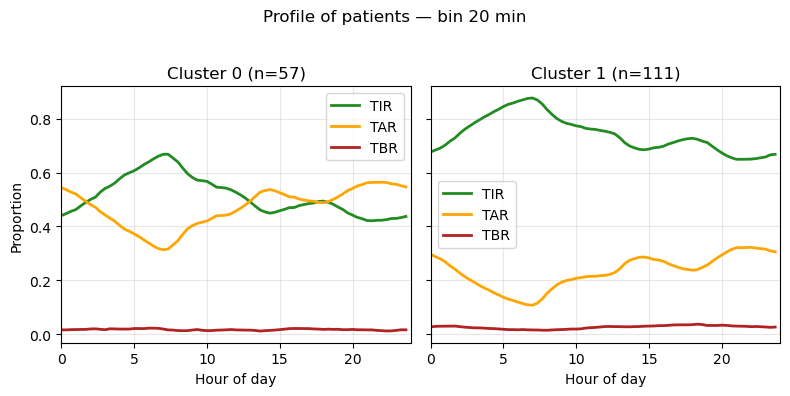

bin=20min method=euclidean k=3 silhouette=0.213


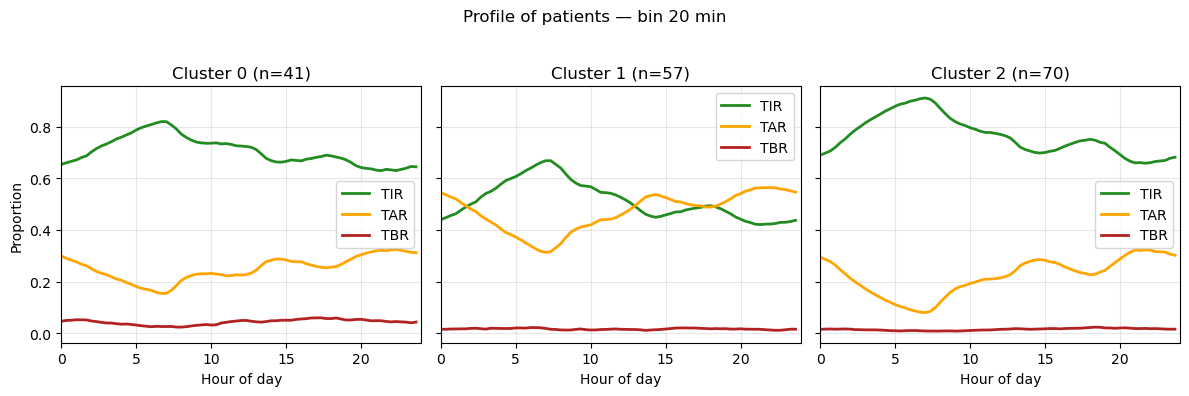

bin=20min method=euclidean k=4 silhouette=0.172


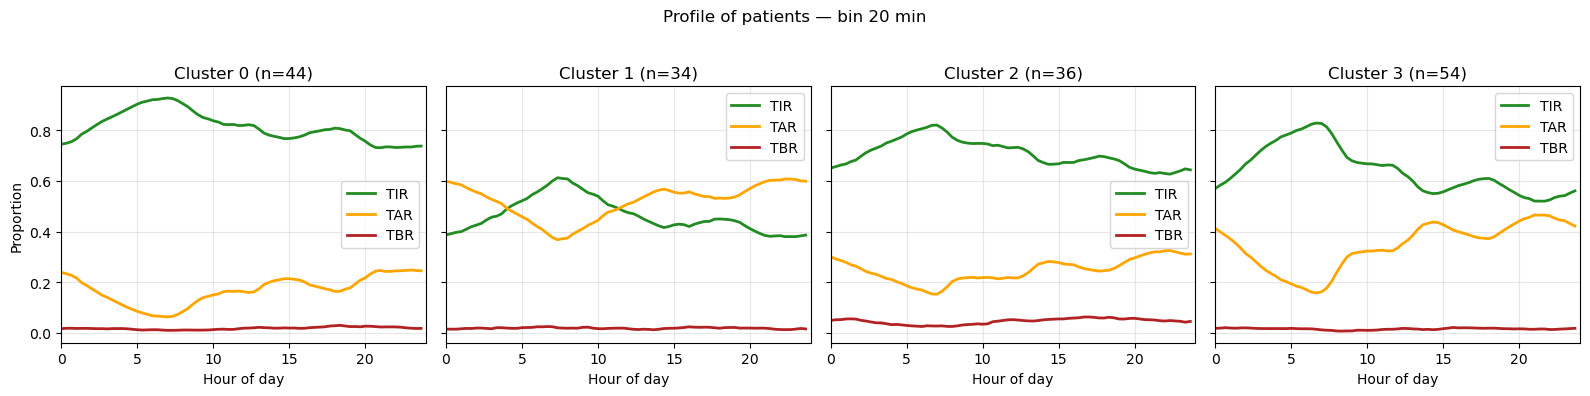

bin=20min method=euclidean k=5 silhouette=0.165


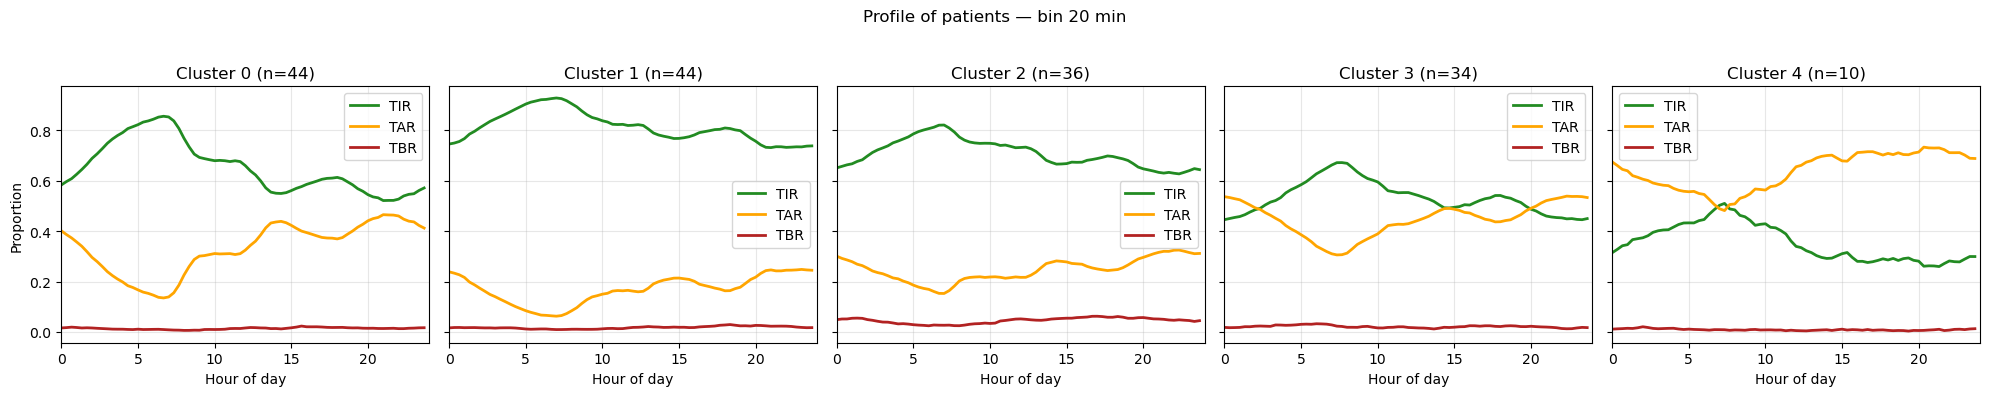

bin=20min method=corr k=2 silhouette=0.397


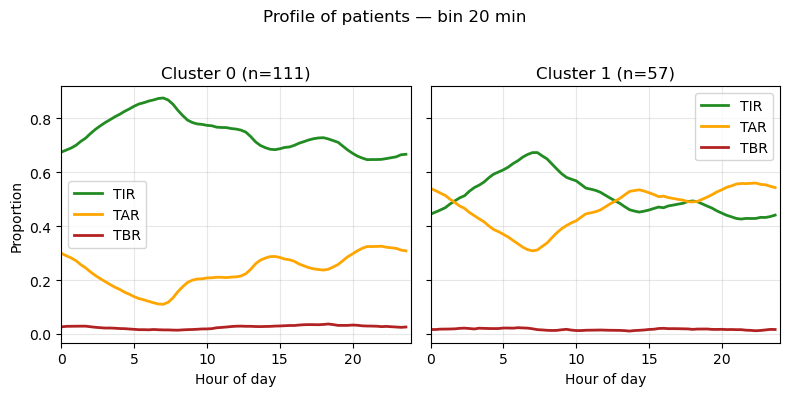

bin=20min method=corr k=3 silhouette=0.351


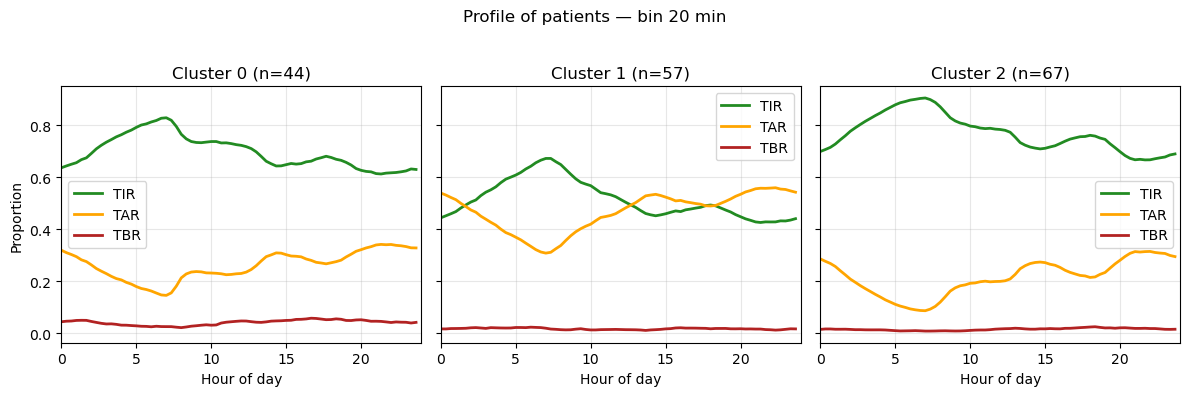

bin=20min method=corr k=4 silhouette=0.305


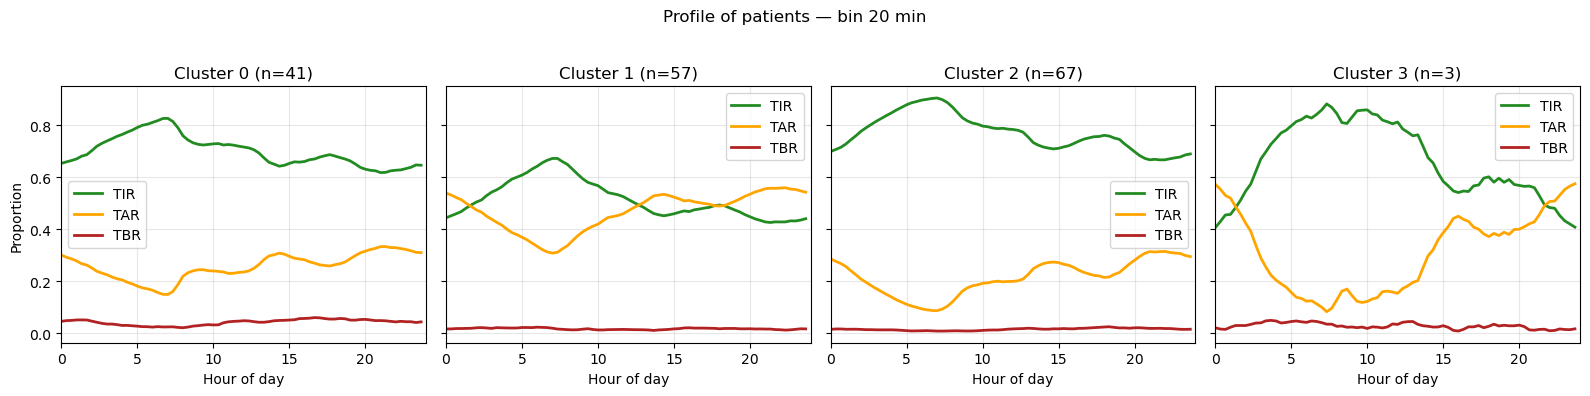

bin=20min method=corr k=5 silhouette=0.292


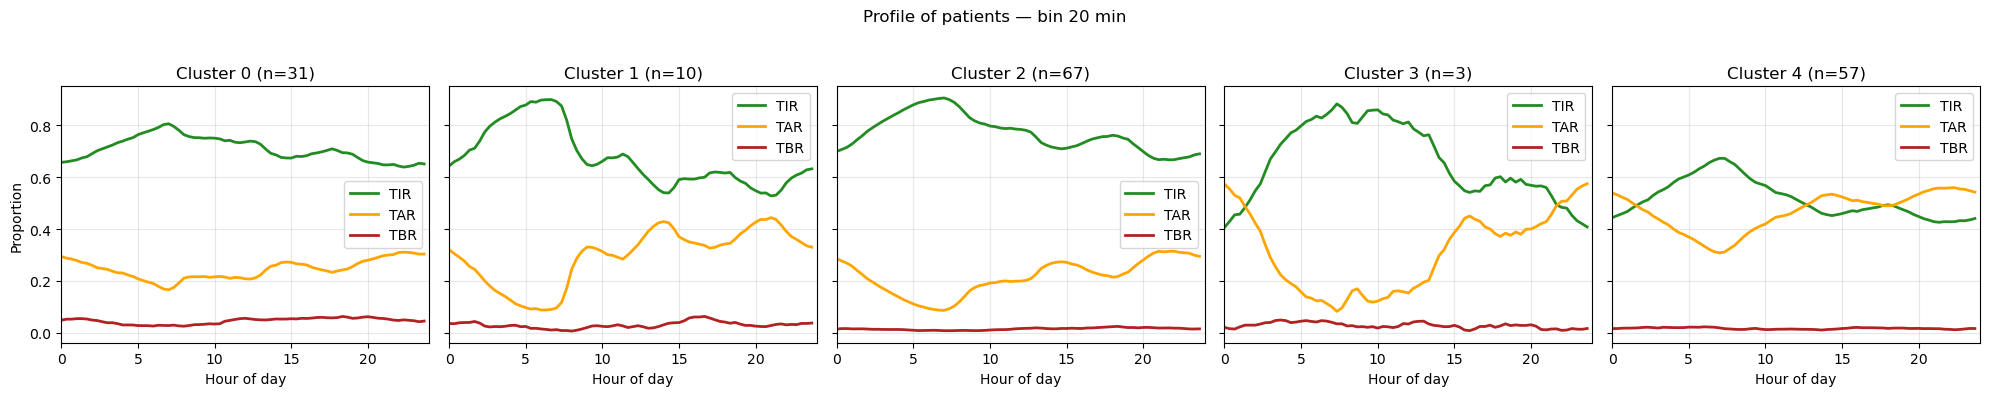

bin=20min method=ward k=2 silhouette=0.271


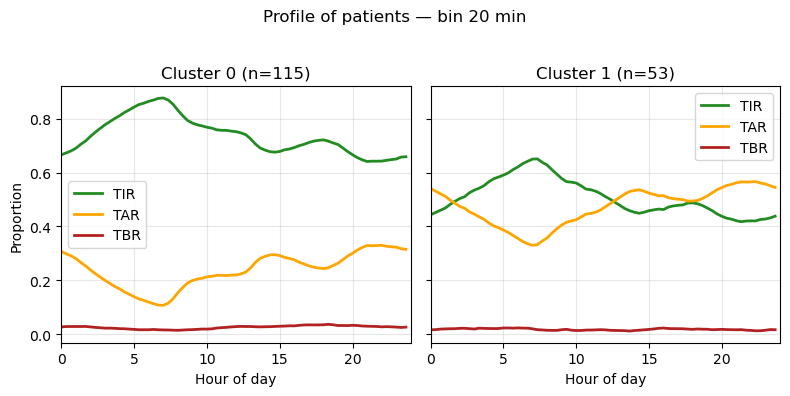

bin=20min method=ward k=3 silhouette=0.188


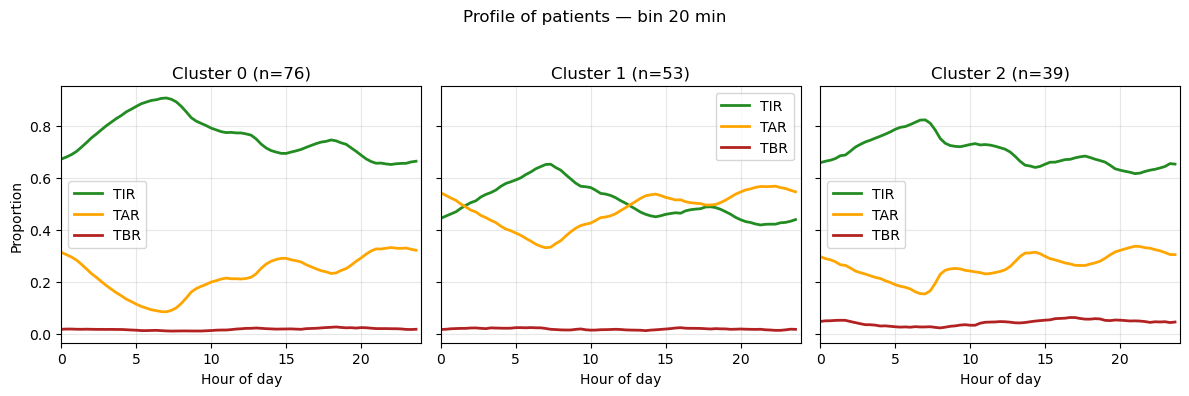

bin=20min method=ward k=4 silhouette=0.131


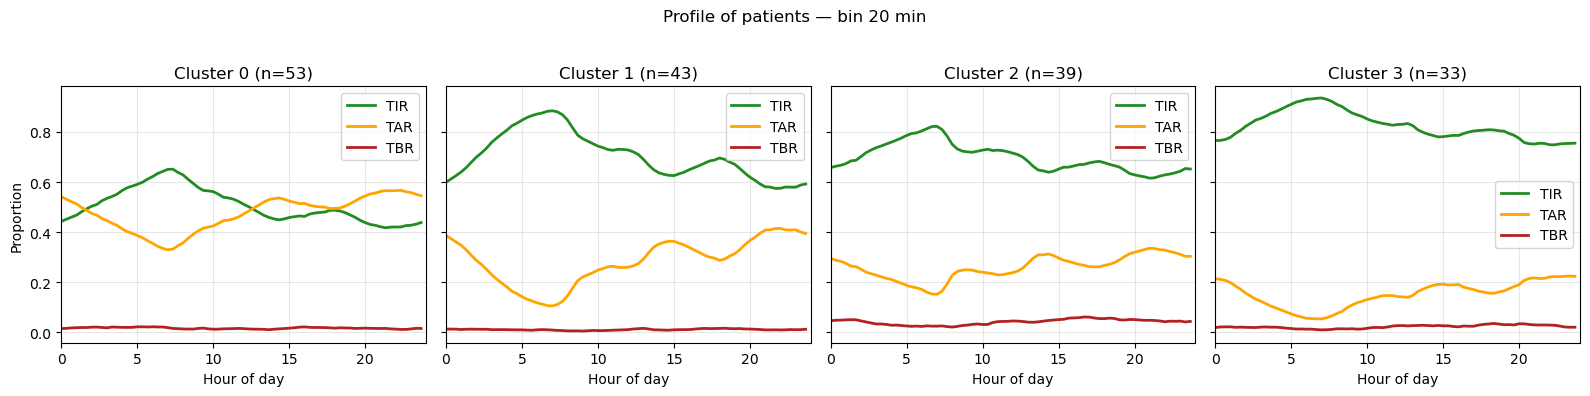

bin=20min method=ward k=5 silhouette=0.130


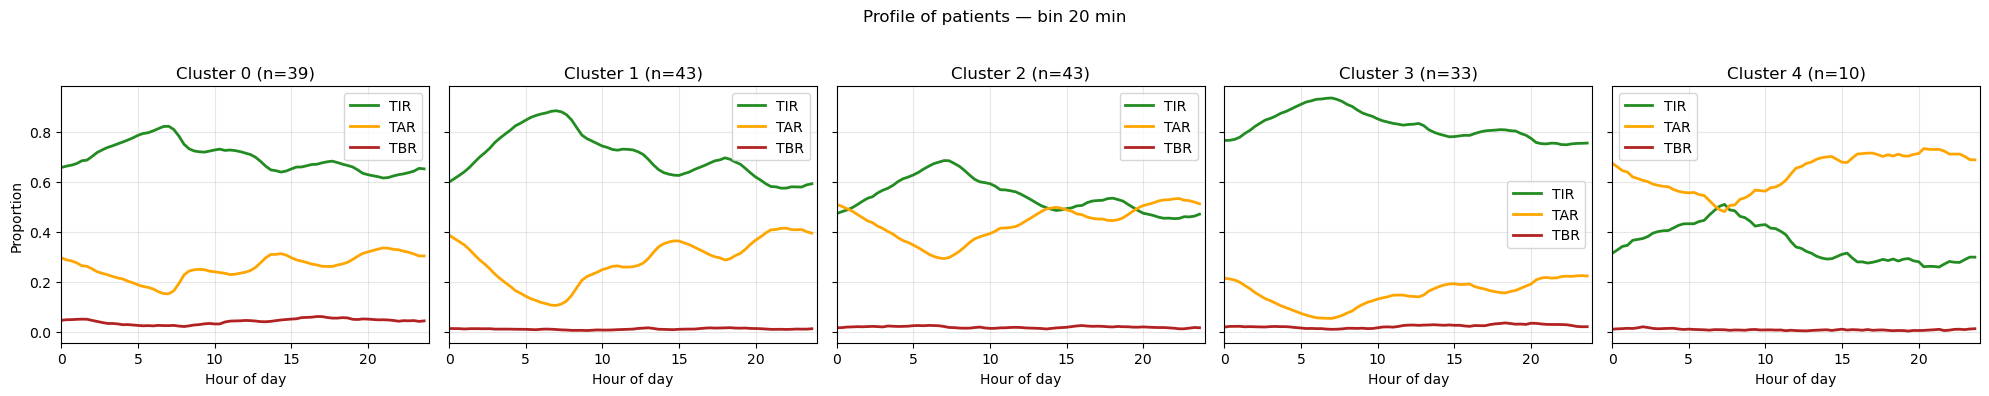

bin=30min method=euclidean k=2 silhouette=0.276


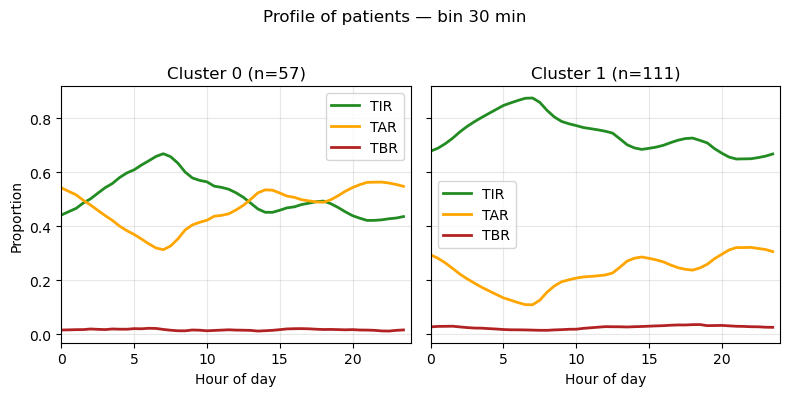

bin=30min method=euclidean k=3 silhouette=0.214


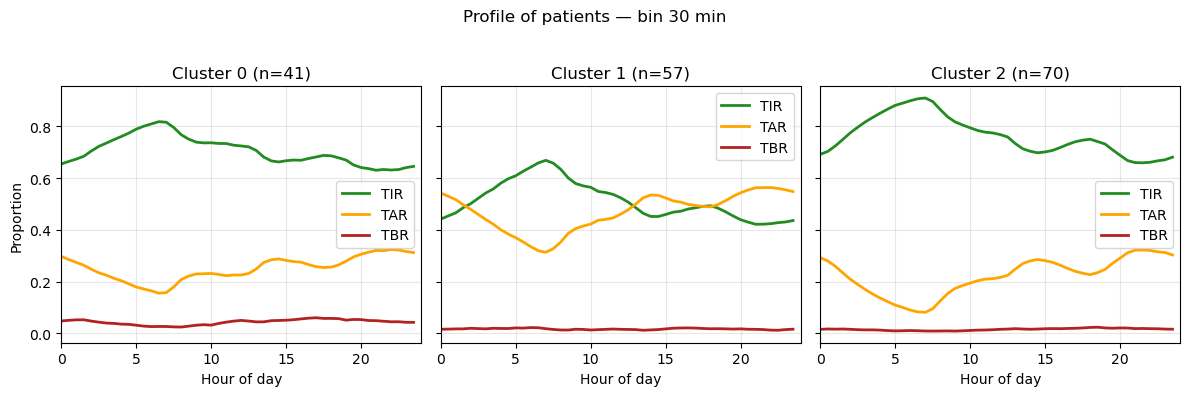

bin=30min method=euclidean k=4 silhouette=0.171


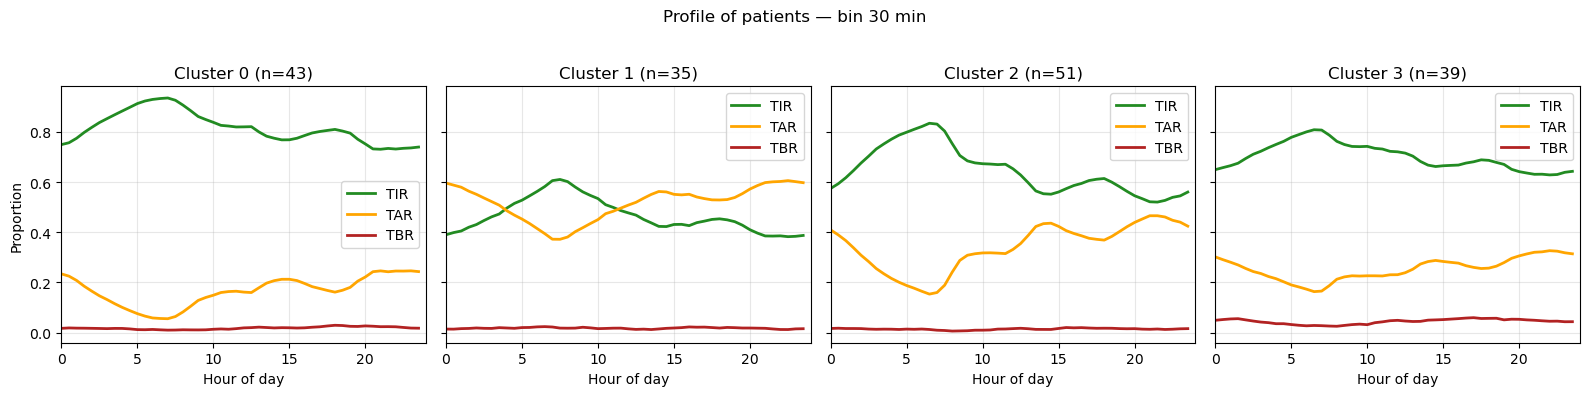

bin=30min method=euclidean k=5 silhouette=0.166


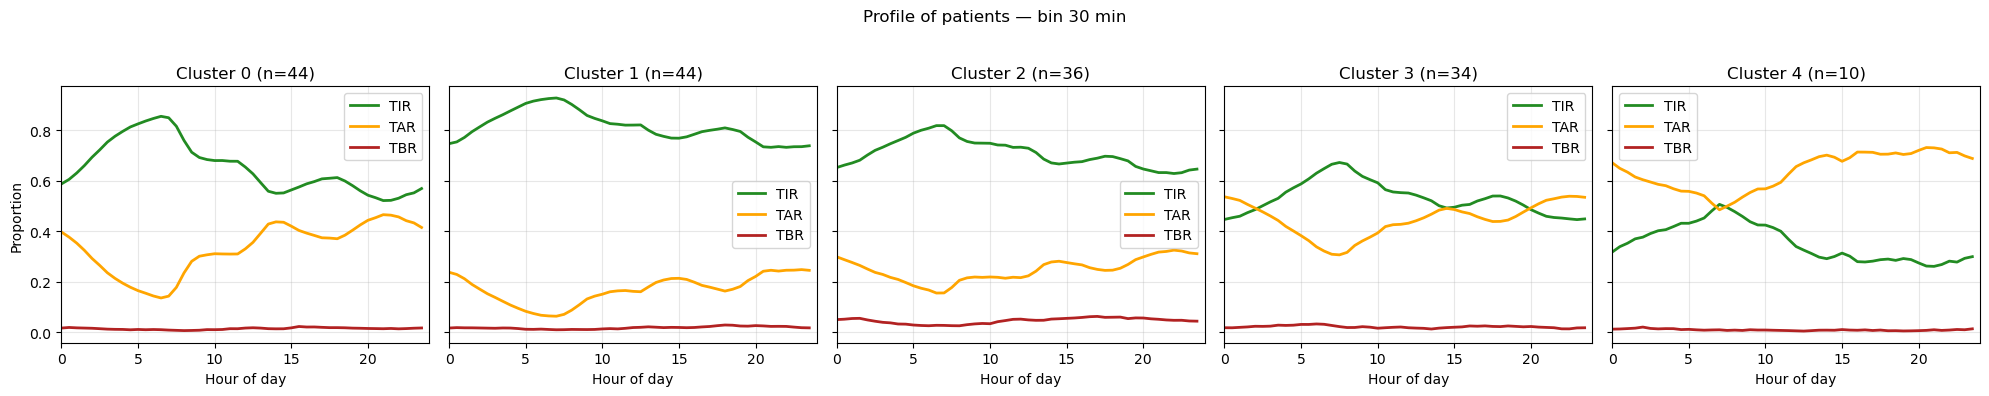

bin=30min method=corr k=2 silhouette=0.398


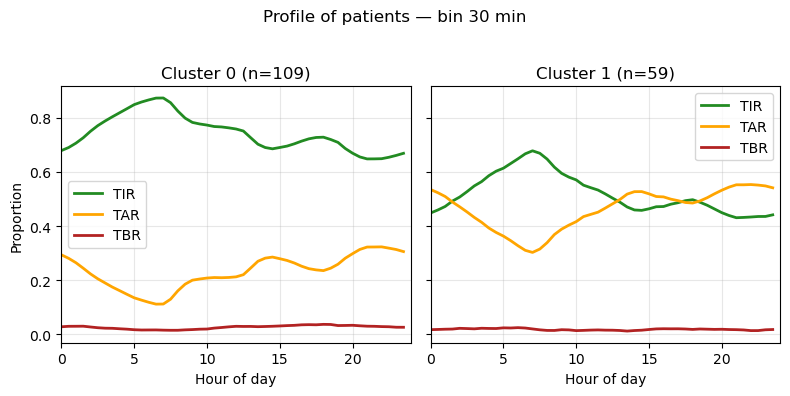

bin=30min method=corr k=3 silhouette=0.354


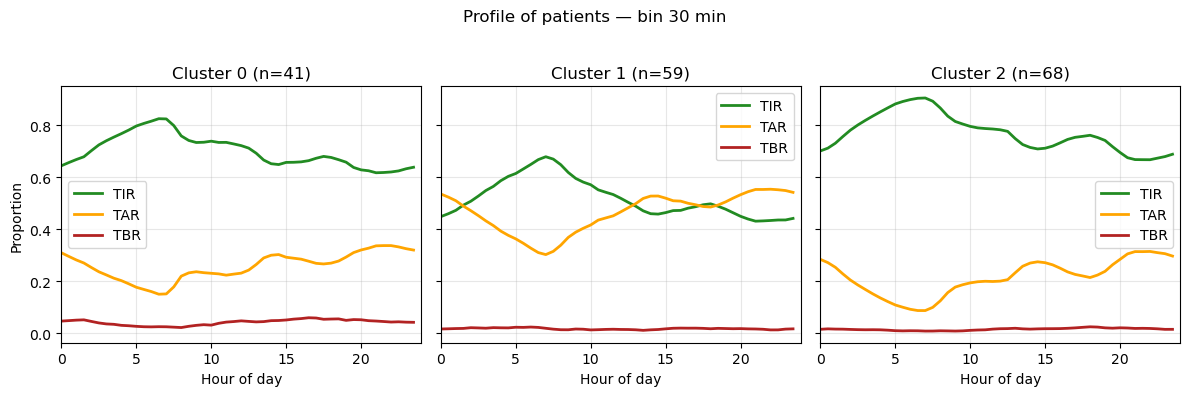

bin=30min method=corr k=4 silhouette=0.321


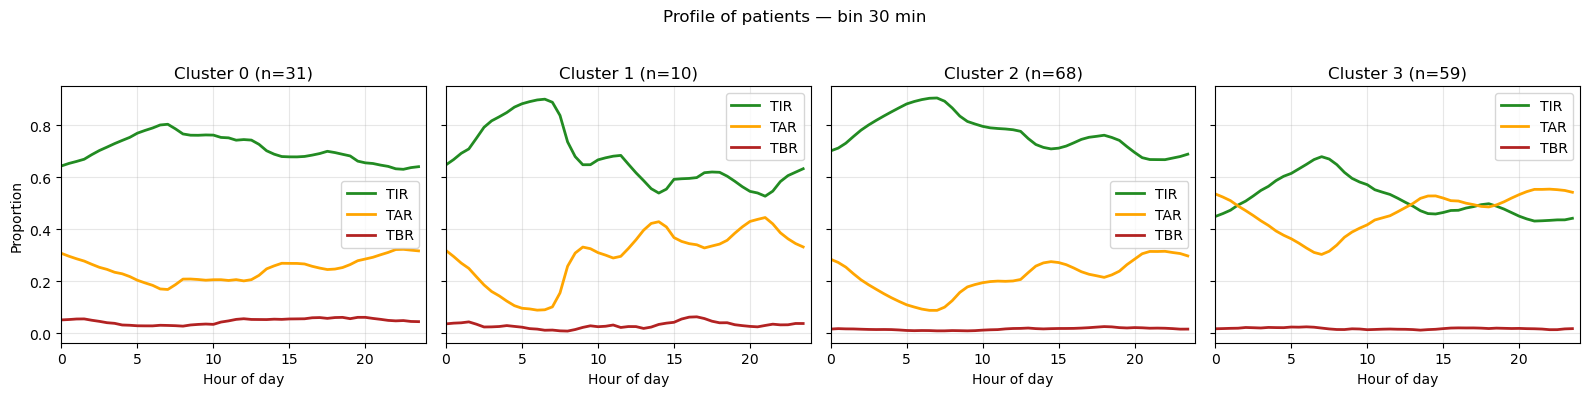

bin=30min method=corr k=5 silhouette=0.286


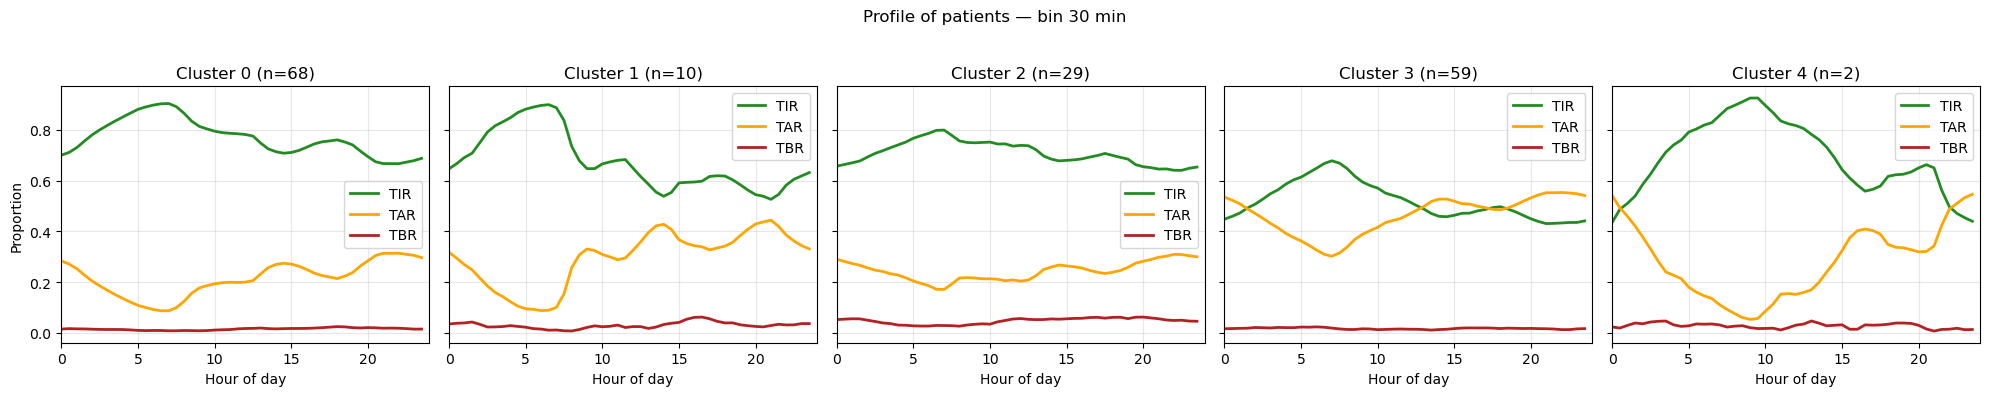

bin=30min method=ward k=2 silhouette=0.243


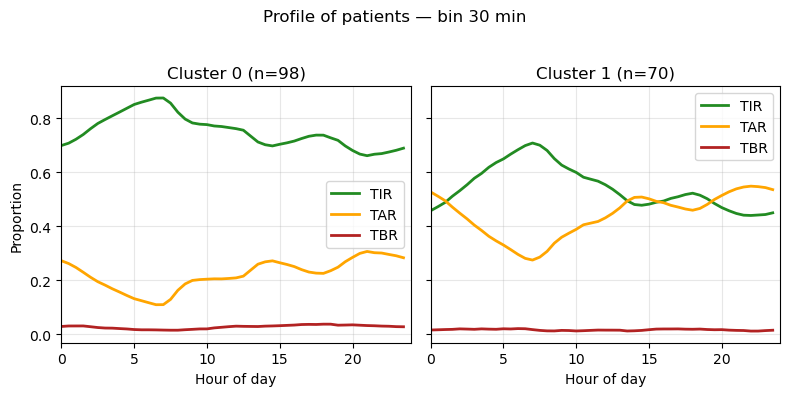

bin=30min method=ward k=3 silhouette=0.189


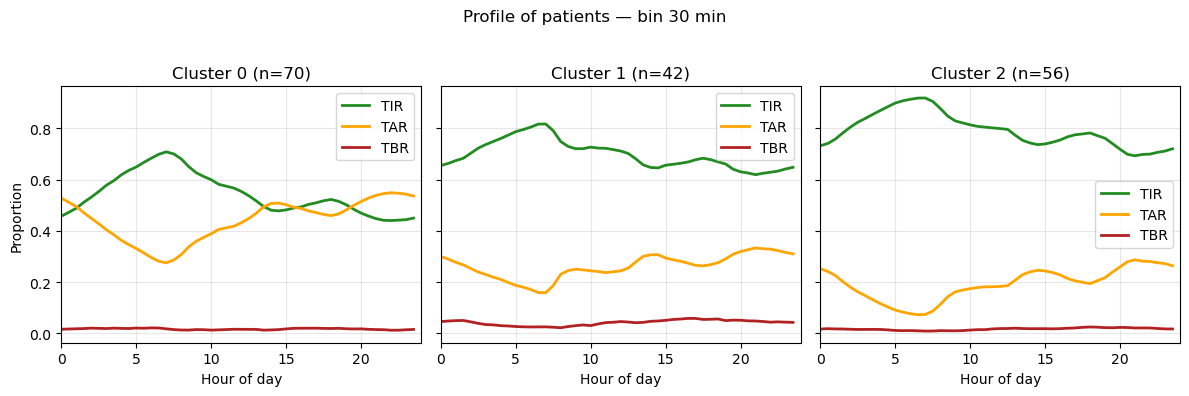

bin=30min method=ward k=4 silhouette=0.180


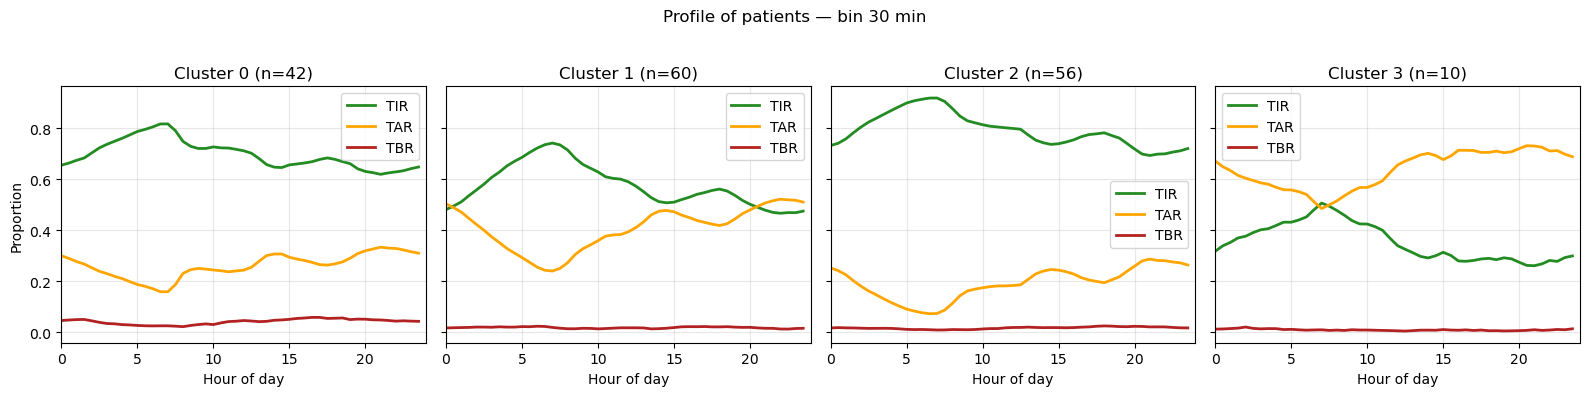

bin=30min method=ward k=5 silhouette=0.140


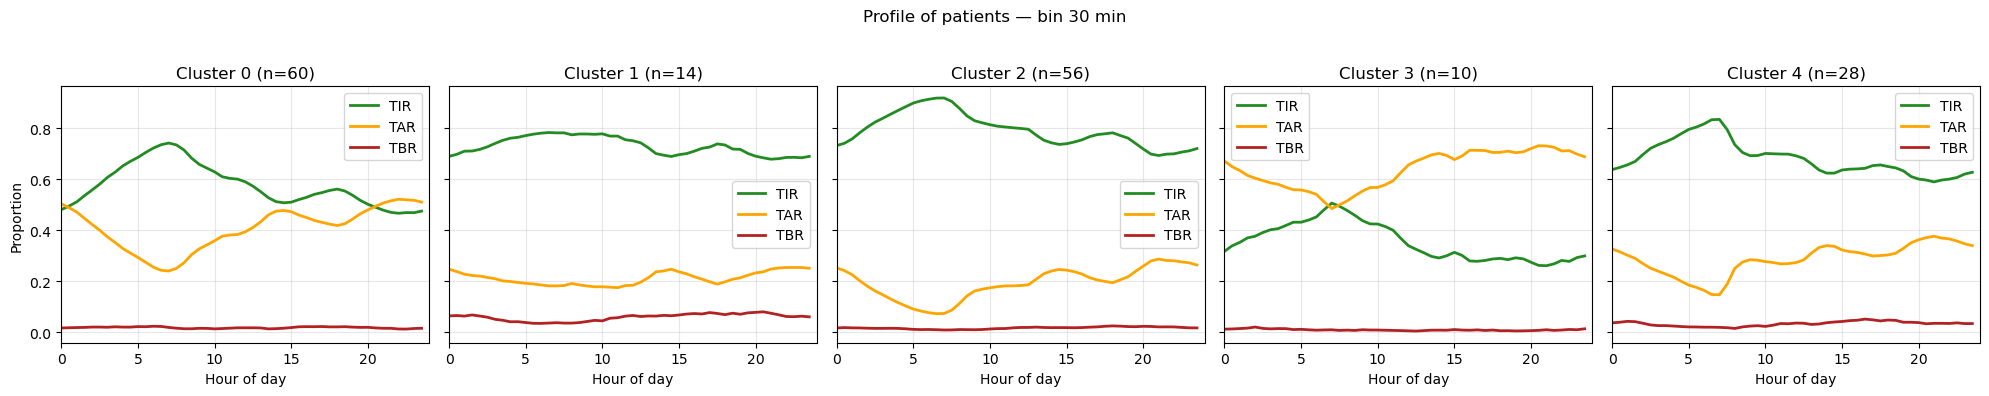

bin=60min method=euclidean k=2 silhouette=0.277


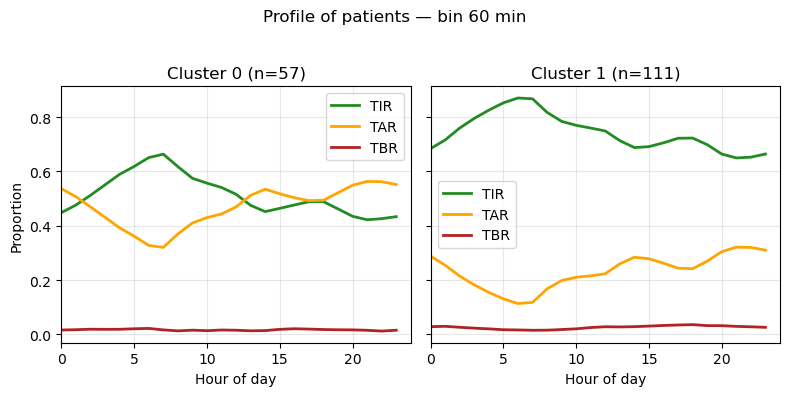

bin=60min method=euclidean k=3 silhouette=0.220


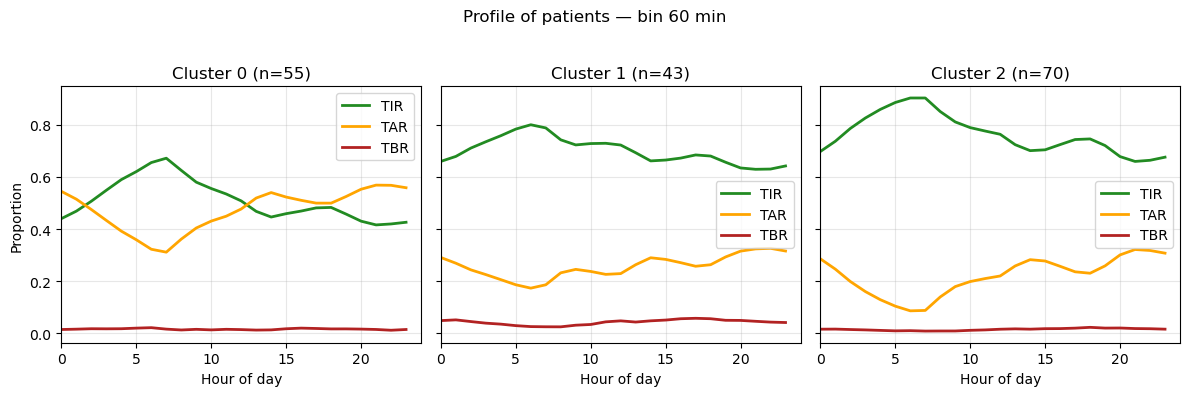

bin=60min method=euclidean k=4 silhouette=0.173


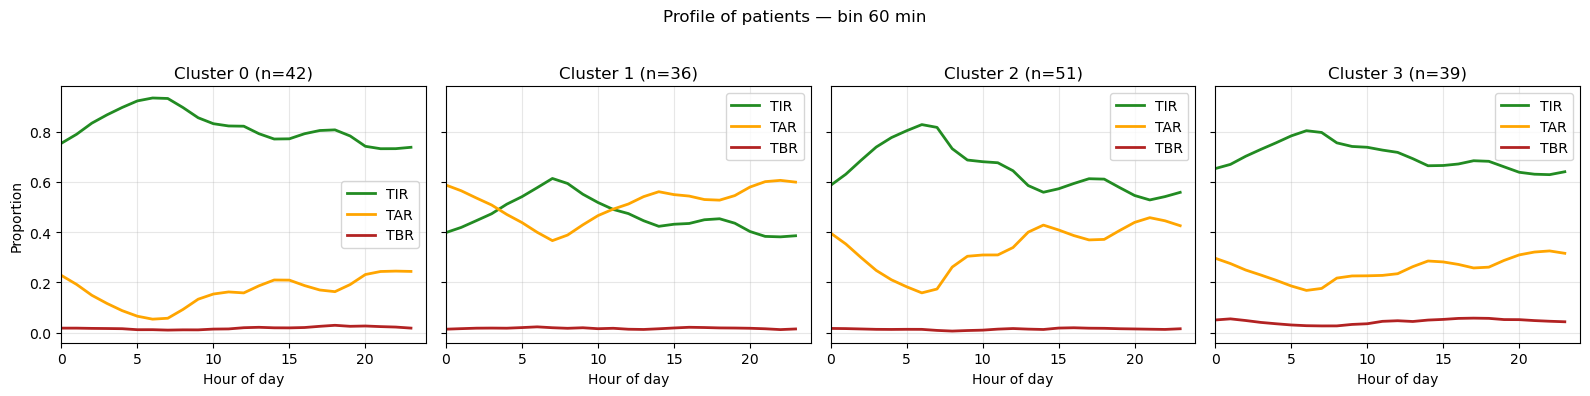

bin=60min method=euclidean k=5 silhouette=0.170


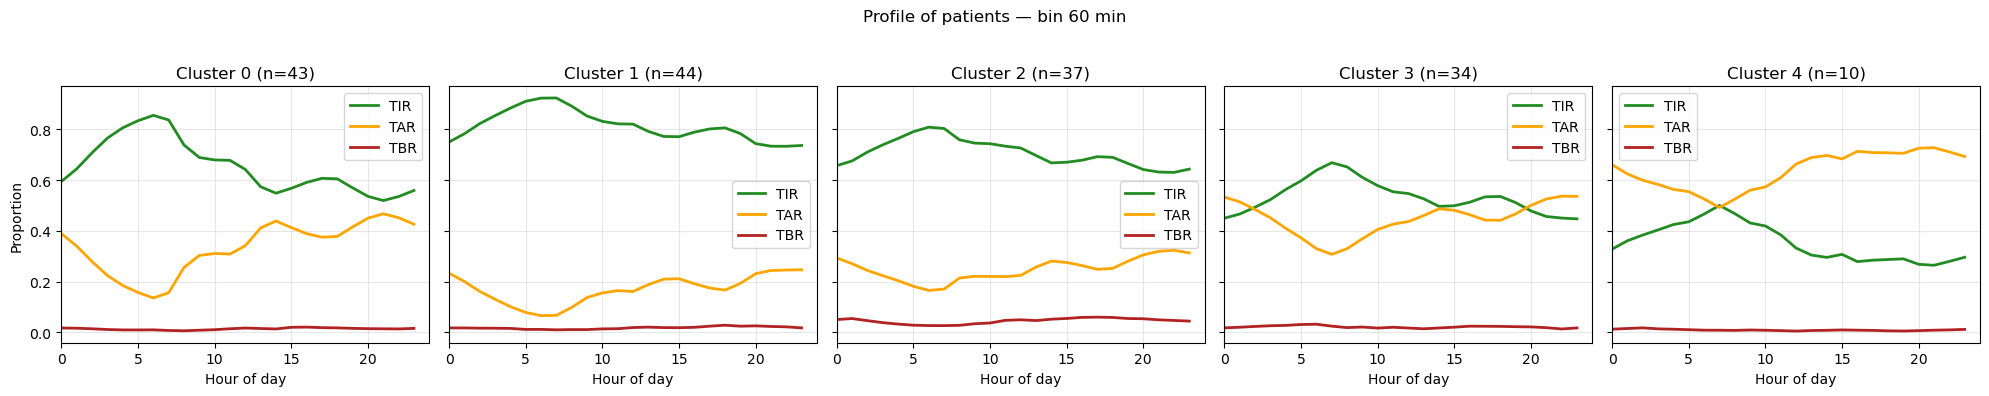

bin=60min method=corr k=2 silhouette=0.403


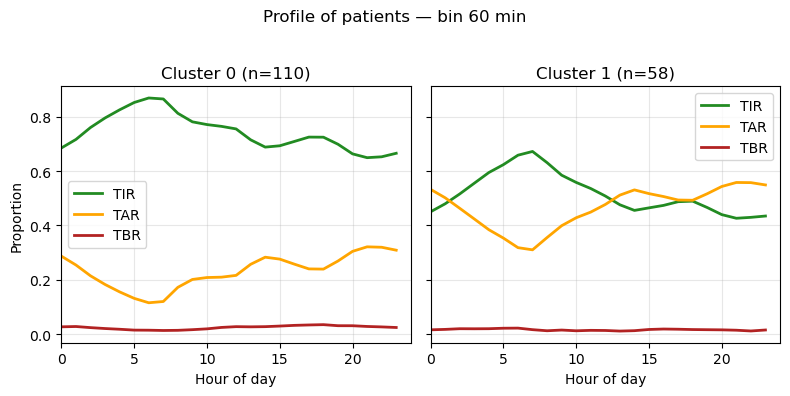

bin=60min method=corr k=3 silhouette=0.367


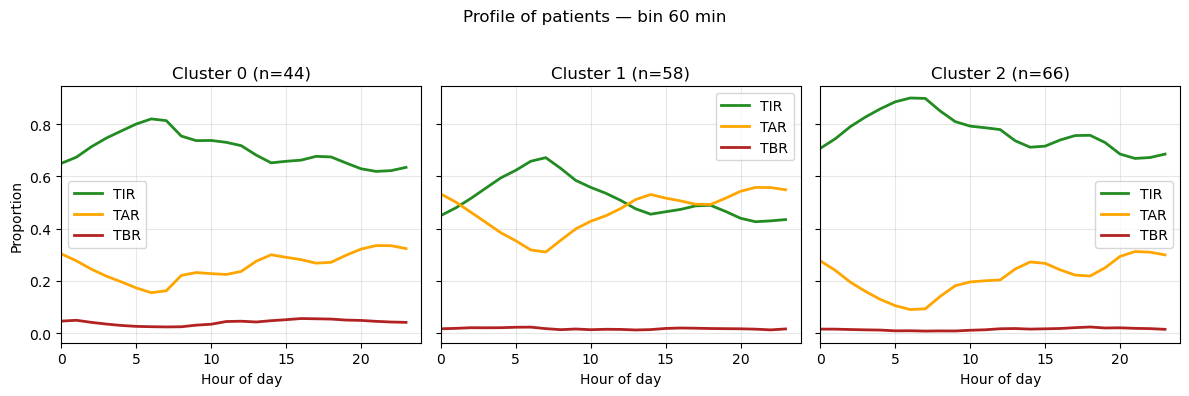

bin=60min method=corr k=4 silhouette=0.306


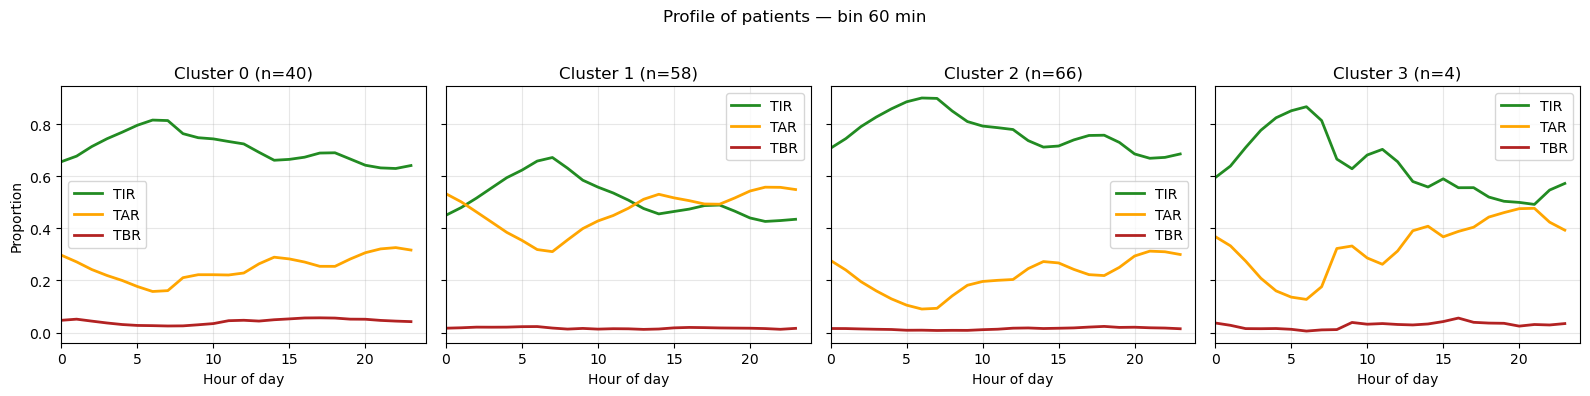

bin=60min method=corr k=5 silhouette=0.254


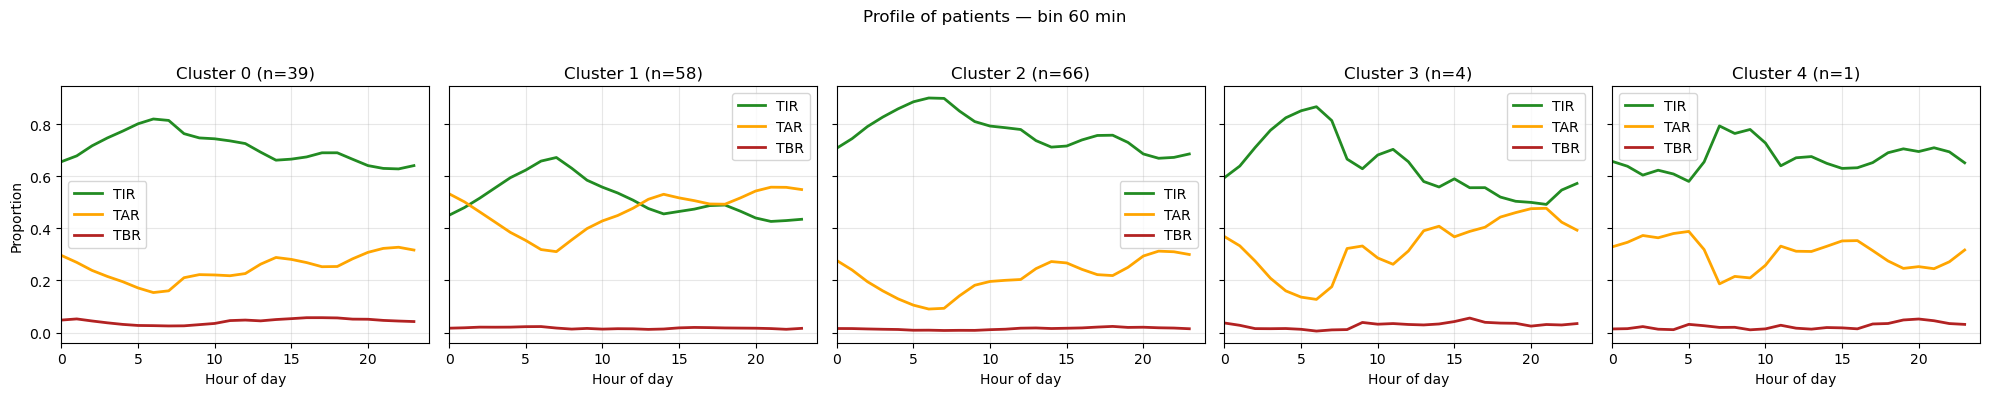

bin=60min method=ward k=2 silhouette=0.248


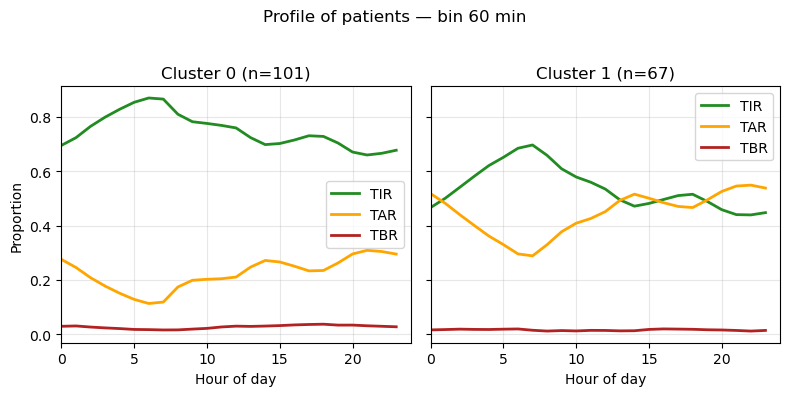

bin=60min method=ward k=3 silhouette=0.189


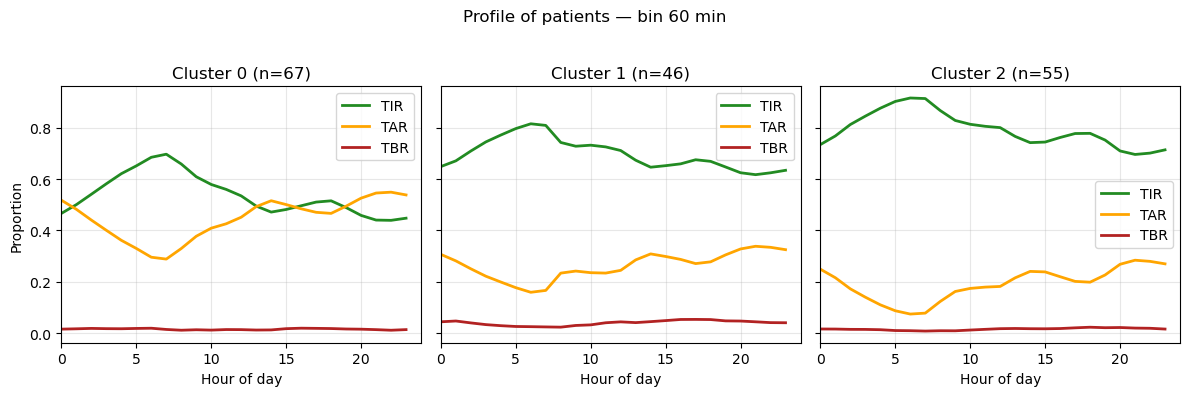

bin=60min method=ward k=4 silhouette=0.168


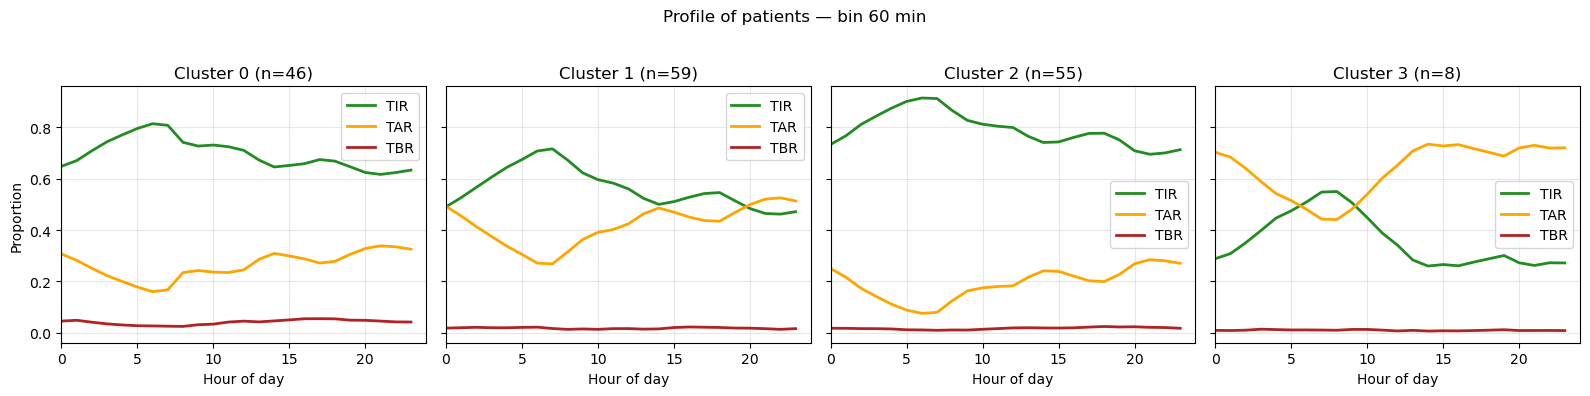

bin=60min method=ward k=5 silhouette=0.130


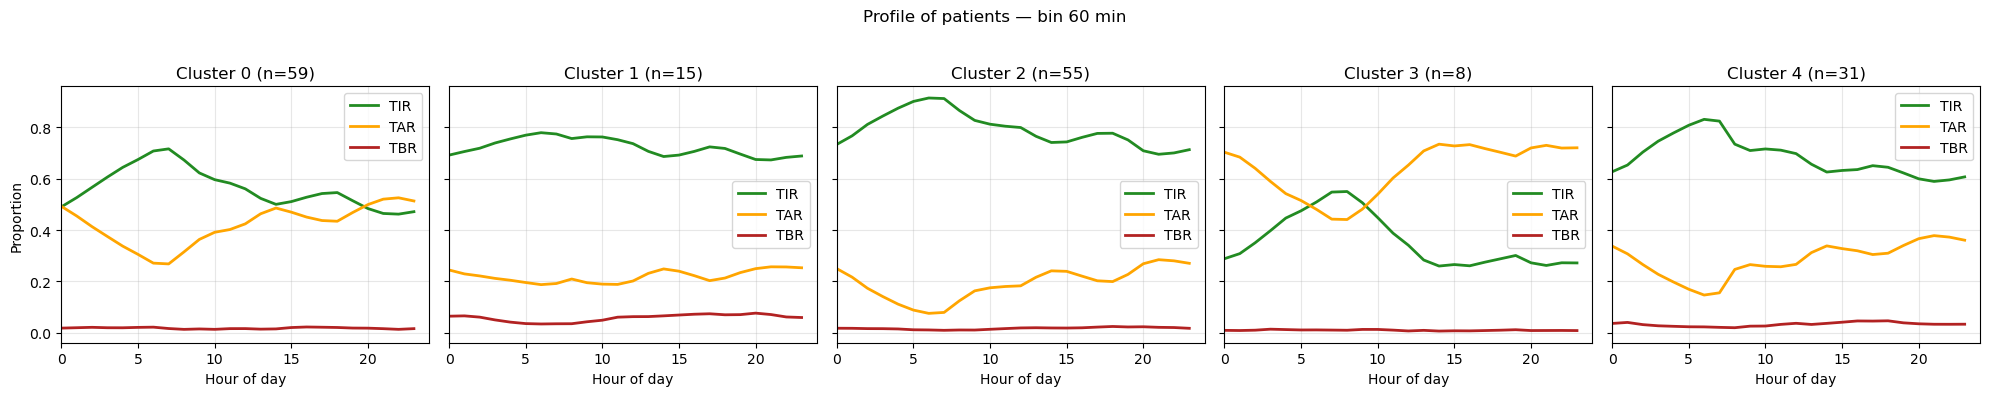

In [163]:
results = run_clustering_experiments(dclp3, bin_sizes=[15,20,30,60], cluster_counts=[2,3,4, 5], methods=['euclidean','corr', 'ward'])

### Best result - bin=60min method=corr k=2 

bin=60min method=corr k=2 silhouette=0.403


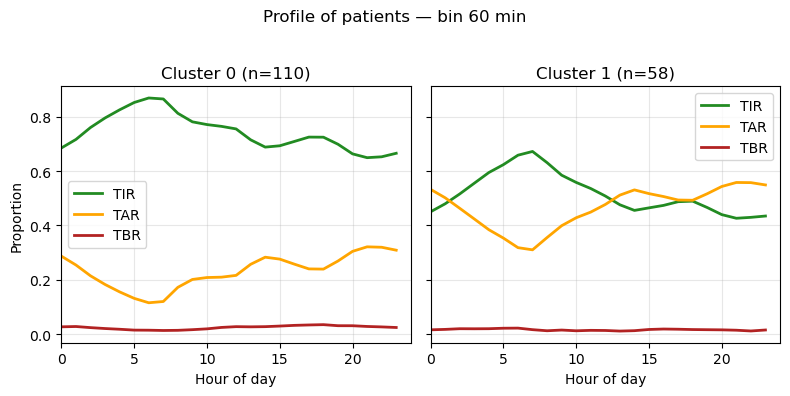

In [164]:
# bin=60min method=corr k=2 silhouette=0.403
results_best = run_clustering_experiments(dclp3, bin_sizes=[60], cluster_counts=[2], methods=['corr'])

## Theory

1. complete linkage

* takes into account the worst or most distant pair of points between clusters
* produces compact, dense clusters
* sensitive to outliers
* correlation with distance works well when patients are clearly divided into groups with high vs. low variability

2. single linkage

* connects clusters by nearest pair point
* tends to create chain clustering, but in the case of glucose curves, “edge cases” can be identified (extreme nocturnal hypos/dawn effects)
* correlation distance works well here

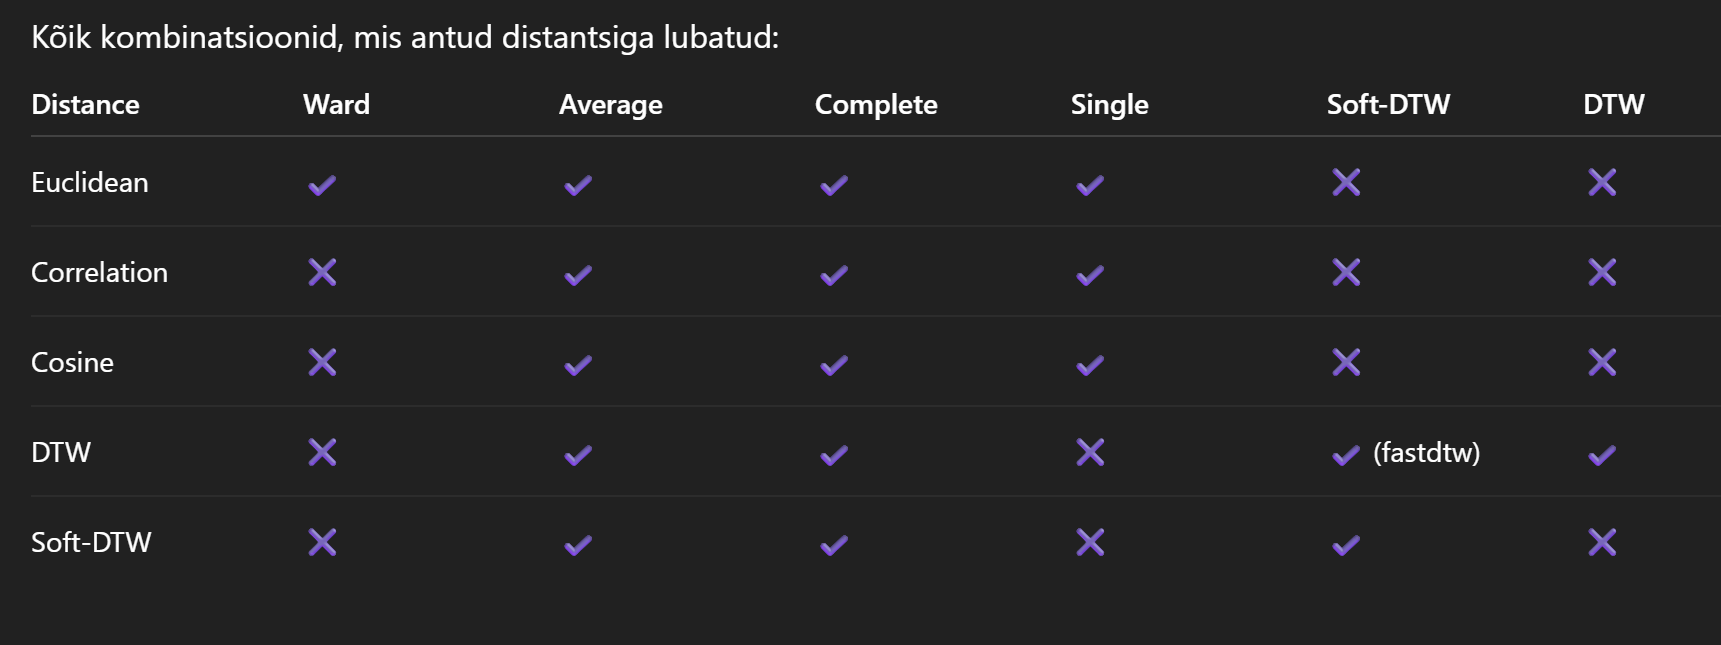

## Experiment 2 -- w/ different linkages

In [165]:
def bin_time_series(df, bin_minutes=30):
    df = df.copy()

    df["DataDtTm"] = pd.to_datetime(df["DataDtTm"])

    # Resample per patient
    ts = (
        df.set_index("DataDtTm")
          .groupby("PtID")["CGM_mmol"]
          .resample(f"{bin_minutes}T")
          .mean()
          .reset_index()
    )

    # pivot a row per PtID
    pivot = (
        ts.pivot(index="PtID", columns="DataDtTm", values="CGM_mmol")
          .fillna(method="ffill", axis=1)
          .fillna(method="bfill", axis=1)
    )

    return pivot

In [166]:
# 2) Distance functions

def dist_euclidean(X):
    return squareform(pdist(X, metric="euclidean"))

def dist_manhattan(X):
    return squareform(pdist(X, metric="cityblock"))

def dist_cosine(X):
    return squareform(pdist(X, metric="cosine"))

def dist_corr(X):
    return squareform(pdist(X, metric=lambda u,v: 1 - np.corrcoef(u, v)[0,1]))

def dist_dtw(X):
    n = len(X)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            d, _ = fastdtw(X[i], X[j])
            D[i,j] = d
            D[j,i] = d
    return D

def dist_softdtw(X, gamma=1.0):
    n = len(X)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            d = soft_dtw(X[i].reshape(-1,1), X[j].reshape(-1,1), gamma=gamma)
            D[i,j] = d
            D[j,i] = d
    return D

In [167]:
# 3) Wrapper dist chooser

def compute_distance(X, method):
    if method == "euclidean":
        return dist_euclidean(X)
    if method == "manhattan":
        return dist_manhattan(X)
    if method == "cosine":
        return dist_cosine(X)
    if method == "corr":
        return dist_corr(X)
    if method == "dtw":
        return dist_dtw(X)
    if method == "softdtw":
        return dist_softdtw(X)
    raise ValueError(f"Unknown distance: {method}")

In [168]:
# 4) Allowed linkages for each distance

def allowed_linkages(dist_method):
    if dist_method in ["euclidean"]:
        return ["ward", "average", "complete", "single"]
    if dist_method in ["corr", "cosine", "manhattan"]:
        return ["average", "complete", "single"]
    if dist_method in ["dtw", "softdtw"]:
        return ["average", "complete"]  
    return []


In [169]:
# 5) Main: Clustering core

def run_clustering(X, dist_method, linkage, k):
    D = compute_distance(X, dist_method)

    if linkage == "ward" and dist_method != "euclidean":
        raise ValueError("Ward linkage requires euclidean distance.")

    model = AgglomerativeClustering(
        n_clusters=k,
        metric="precomputed",
        linkage=linkage
    )
    labels = model.fit_predict(D)

    score = silhouette_score(D, labels, metric="precomputed")

    return labels, score, D

In [170]:
# 6) Full experiment pipeline

def run_all_experiments(df,
                        bin_sizes=[20,30,60],
                        dist_methods=["euclidean","corr","cosine","manhattan"],
                        cluster_counts=[2,3,4]):
    results = {}

    for bin_m in bin_sizes:
        print(f"\n### Binning = {bin_m} min ###")

        # --- Binning & feature extraction for visualization ---
        df_binned, n_bins = prepare_bins(df, bin_minutes=bin_m)
        features, n_bins = build_profile_features(df_binned, n_bins)

        # --- Standardize / scale for clustering ---
        X = features.values
        scaler = StandardScaler()
        Xs = scaler.fit_transform(X)

        for dist in dist_methods:
            linkages = allowed_linkages(dist)

            for link in linkages:
                for k in cluster_counts:

                    print(f"Trying: bin={bin_m}, dist={dist}, linkage={link}, k={k}")

                    try:
                        labels, score, D = run_clustering(Xs, dist, link, k)
                    except Exception as e:
                        print("  → failed:", e)
                        continue

                    key = (bin_m, dist, link, k)
                    results[key] = {
                        "labels": labels,
                        "silhouette": score,
                        "dist_matrix": D,
                        "X_scaled": Xs,
                        "scaler": scaler,
                        "features": features,
                        "n_bins": n_bins
                    }

    return results

In [173]:
# subset = dclp3[dclp3['PtID'].isin([6, 7, 8, 9, 10])]
np.random.seed(712)
results = run_all_experiments(
    df=dclp3,
    bin_sizes=[15, 20,30,60],
    dist_methods=["euclidean","corr","cosine","manhattan", "ward"],
    cluster_counts=[2,3,4, 5]
)


### Binning = 15 min ###
Trying: bin=15, dist=euclidean, linkage=ward, k=2
  → failed: precomputed was provided as metric. Ward can only work with euclidean distances.
Trying: bin=15, dist=euclidean, linkage=ward, k=3
  → failed: precomputed was provided as metric. Ward can only work with euclidean distances.
Trying: bin=15, dist=euclidean, linkage=ward, k=4
  → failed: precomputed was provided as metric. Ward can only work with euclidean distances.
Trying: bin=15, dist=euclidean, linkage=ward, k=5
  → failed: precomputed was provided as metric. Ward can only work with euclidean distances.
Trying: bin=15, dist=euclidean, linkage=average, k=2
Trying: bin=15, dist=euclidean, linkage=average, k=3
Trying: bin=15, dist=euclidean, linkage=average, k=4
Trying: bin=15, dist=euclidean, linkage=average, k=5
Trying: bin=15, dist=euclidean, linkage=complete, k=2
Trying: bin=15, dist=euclidean, linkage=complete, k=3
Trying: bin=15, dist=euclidean, linkage=complete, k=4
Trying: bin=15, dist=euclide

In [174]:
# Sort out best 5 clustering results
best_5 = sorted(
    results.items(), 
    key=lambda item: item[1]["silhouette"], 
    reverse=True
)[:5]

for i, (key, value) in enumerate(best_5, 1):
    bin_m, dist, linkage, k = key  # nüüd võtame kõik 4 elementi
    print(f"{i}. bin={bin_m} min, dist={dist}, linkage={linkage}, k={k}, silhouette={value['silhouette']:.3f}")

1. bin=60 min, dist=euclidean, linkage=average, k=2, silhouette=0.442
2. bin=60 min, dist=corr, linkage=average, k=2, silhouette=0.403
3. bin=15 min, dist=corr, linkage=average, k=2, silhouette=0.399
4. bin=30 min, dist=corr, linkage=average, k=2, silhouette=0.398
5. bin=20 min, dist=corr, linkage=average, k=2, silhouette=0.397


In [175]:
results_by_bin = defaultdict(list)
for key, value in results.items():
    bin_m, dist, link, k = key
    entry = {"dist": dist, "linkage": link, "k": k, "silhouette": value["silhouette"]}
    results_by_bin[bin_m].append(entry)

# Take TOP5 for each bin (15, 20, 30, 60 min)
top5_per_bin = {}
for bin_size, res_list in results_by_bin.items():
    top5 = sorted(res_list, key=lambda x: x['silhouette'], reverse=True)[:5]
    top5_per_bin[bin_size] = top5

for bin_size, top5 in top5_per_bin.items():
    print(f"\n### Bin = {bin_size} min ###")
    for i, r in enumerate(top5, 1):
        print(f"{i}. dist={r['dist']}, linkage={r['linkage']}, k={r['k']}, silhouette={r['silhouette']:.3f}")


### Bin = 15 min ###
1. dist=corr, linkage=average, k=2, silhouette=0.399
2. dist=cosine, linkage=complete, k=2, silhouette=0.391
3. dist=cosine, linkage=average, k=2, silhouette=0.390
4. dist=corr, linkage=complete, k=2, silhouette=0.389
5. dist=cosine, linkage=average, k=3, silhouette=0.360

### Bin = 20 min ###
1. dist=corr, linkage=average, k=2, silhouette=0.397
2. dist=cosine, linkage=complete, k=2, silhouette=0.390
3. dist=cosine, linkage=average, k=2, silhouette=0.390
4. dist=manhattan, linkage=average, k=2, silhouette=0.376
5. dist=manhattan, linkage=complete, k=2, silhouette=0.373

### Bin = 30 min ###
1. dist=corr, linkage=average, k=2, silhouette=0.398
2. dist=cosine, linkage=complete, k=2, silhouette=0.396
3. dist=corr, linkage=complete, k=2, silhouette=0.390
4. dist=cosine, linkage=average, k=2, silhouette=0.383
5. dist=manhattan, linkage=complete, k=2, silhouette=0.376

### Bin = 60 min ###
1. dist=euclidean, linkage=average, k=2, silhouette=0.442
2. dist=corr, linkage=a

In [176]:
# Visualise top N results
def plot_top_results(results, top_n=5):
    best_results = sorted(
        results.items(),
        key=lambda item: item[1]["silhouette"],
        reverse=True
    )[:top_n]

    for i, (key, value) in enumerate(best_results, 1):
        bin_m, dist, link, k = key
        print(f"{i}. bin={bin_m} min, dist={dist}, linkage={link}, k={k}, silhouette={value['silhouette']:.3f}")
        plot_cluster_profiles(
            value['features'],
            value['n_bins'],
            bin_m,
            value['labels']
        )

1. bin=60 min, dist=euclidean, linkage=average, k=2, silhouette=0.442


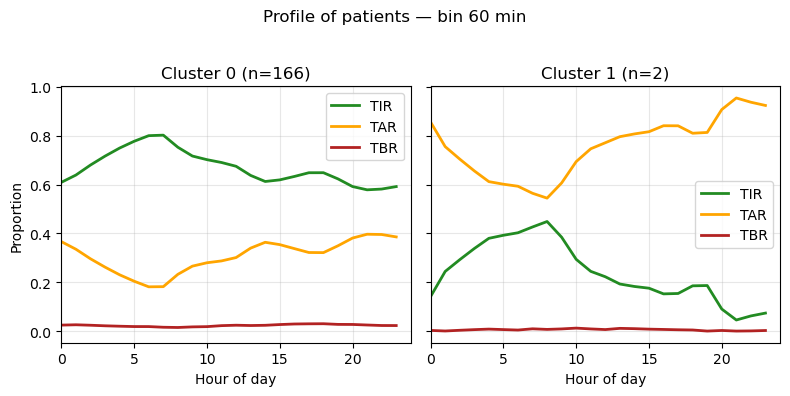

2. bin=60 min, dist=corr, linkage=average, k=2, silhouette=0.403


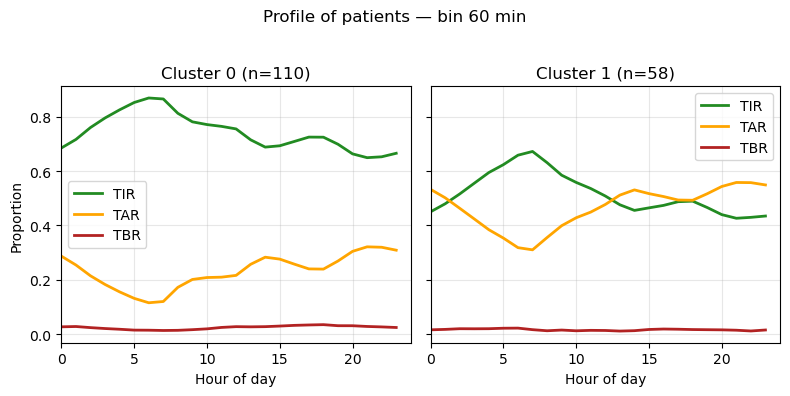

3. bin=15 min, dist=corr, linkage=average, k=2, silhouette=0.399


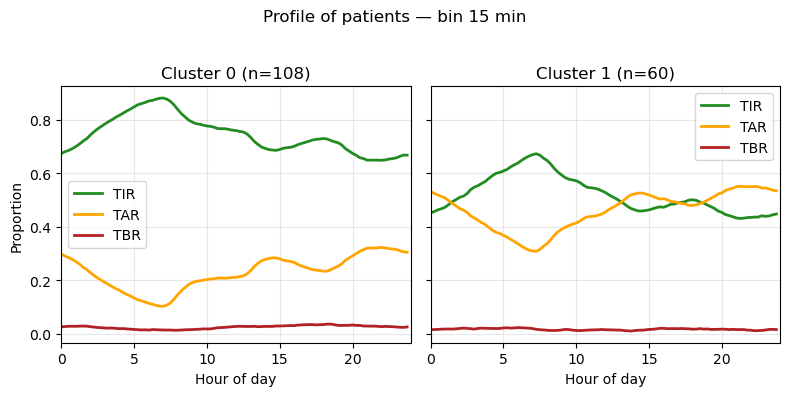

4. bin=30 min, dist=corr, linkage=average, k=2, silhouette=0.398


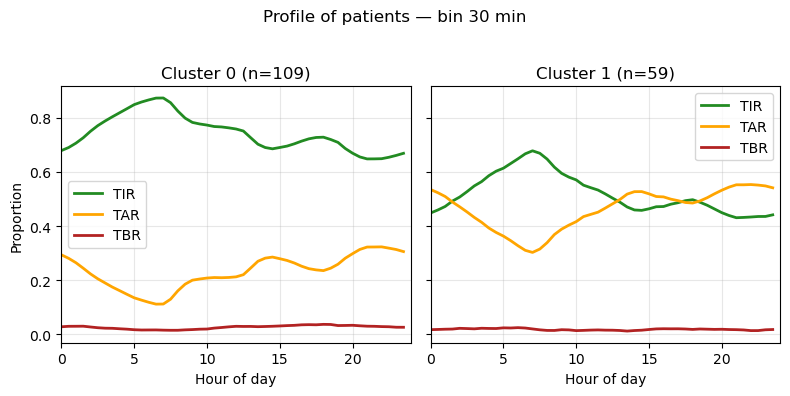

5. bin=20 min, dist=corr, linkage=average, k=2, silhouette=0.397


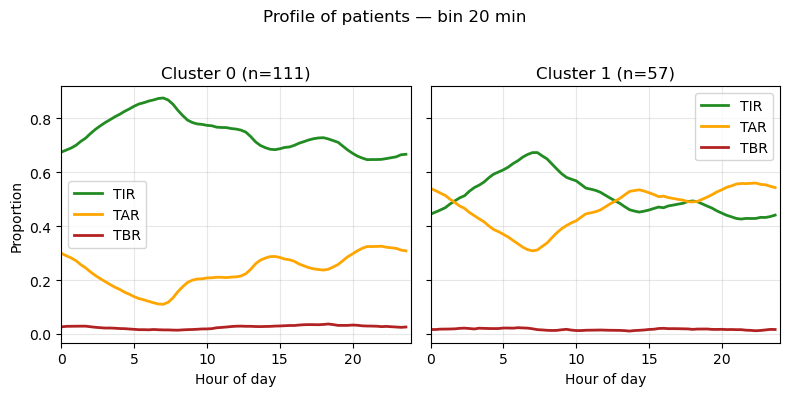

In [177]:
plot_top_results(results, top_n=5)

### ⭐Best best result⭐

**⭐bin=60 min, dist=euclidean, linkage=average, k=2, silhouette=0.442⭐**

In [178]:
# 1. bin=60 min, dist=euclidean, linkage=average, k=2, silhouette=0.442
best_key = (60, "euclidean", "average", 2)

labels = results[best_key]["labels"]
scaler = results[best_key]["scaler"]
X_scaled = results[best_key]["X_scaled"]

In [179]:
# 2. bin=60 min, dist=corr, linkage=average, k=2, silhouette=0.403
best_key = (60, "corr", "average", 2)

labels = results[best_key]["labels"]
scaler = results[best_key]["scaler"]
X_scaled = results[best_key]["X_scaled"]

Try to generate a patient to see to which cluster it will be placed. For that we need to calculate the centroids and use K-means.

In [180]:
def compute_centroids(X_scaled, labels):
    centroids = []
    for c in sorted(set(labels)):
        centroids.append(X_scaled[labels == c].mean(axis=0))
    return np.vstack(centroids)

In [181]:
centroids = compute_centroids(X_scaled, labels)

In [182]:
def predict_cluster_for_new_patient(new_features_raw, scaler, centroids):
    new_scaled = scaler.transform([new_features_raw])  # shape (1, n_features)
    
    dists = np.linalg.norm(new_scaled - centroids, axis=1)
    return np.argmin(dists)

In [183]:
def generate_synthetic_patient(months=6, freq_minutes=5, seed=42):
    np.random.seed(seed)

    # Time vector
    start = pd.Timestamp("2024-01-01")
    end = start + pd.DateOffset(months=months)
    dt_index = pd.date_range(start, end, freq=f"{freq_minutes}T", inclusive="left")

    # Base glycose (mmol/L)
    base = 6.0

    # Circadian rhythm: lower at night, higher during the day
    hours = dt_index.hour + dt_index.minute/60
    circadian = 1.2 * np.sin((hours - 4) * np.pi/12)

    # Food peaks
    meal_peaks = np.zeros(len(dt_index))
    meal_times = [8, 13, 19]  # breakfast, lunch, dinner
    for mt in meal_times:
        meal_peaks += 2.5 * np.exp(-0.5*((hours - mt)/0.8)**2)

    # random interday drift
    day_index = (dt_index - dt_index[0]).days
    day_effect = 0.3 * np.sin(day_index * 2*np.pi/30)

    # random noise (5-min glucose fluctuation)
    noise = np.random.normal(0, 0.5, len(dt_index))

    # Final glucose signal generation
    glucose = base + circadian + meal_peaks + day_effect + noise

    df = pd.DataFrame({
        "DataDtTm": dt_index,
        "CGM_mmol": glucose
    })

    df["PtID"] = "P_SYNTH_001"
    return df

In [184]:
df_patient = generate_synthetic_patient()
df_patient["PtID"] = "NEW_PATIENT"
df_patient.head()

,DataDtTm,CGM_mmol,PtID
0,2024-01-01 00:00:00,5.209127,NEW_PATIENT
1,2024-01-01 00:05:00,4.904974,NEW_PATIENT
2,2024-01-01 00:10:00,5.311775,NEW_PATIENT
3,2024-01-01 00:15:00,5.763751,NEW_PATIENT
4,2024-01-01 00:20:00,4.899941,NEW_PATIENT


In [185]:
# Which cluster does the new patient belong to?
df_new_binned = prepare_bins(df_patient, bin_minutes=60)[0]
new_features, _ = build_profile_features(df_new_binned, 24)

pred = predict_cluster_for_new_patient(
    new_features.values[0],
    scaler,
    centroids
)

print("Patient belongs to cluster no. ", pred)

Patient belongs to cluster no.  0


# Clustering -- a how the weekdays can be clustered for a patient

In [196]:
import calendar
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
import math

### Rolling mean (mmol) -- best!

#### Complete medical history

In [191]:
def cluster_patient_days_experiment_rollingmean(df_patient, bin_sizes=[20,30,60], 
                                    methods=['euclidean','manhattan','corr','ward'], 
                                    cluster_counts=[2,3,4, 5, 6, 7]):
    """
    Clusters patient's days based on rolling mean glucose measurements.

    Parameters:
        df_patient : pd.DataFrame
            Patient's CGM data with 'rolling_mean_mmol' and 'DataDtTm' columns.
        bin_sizes : list of int
            List of bin sizes in minutes.
        methods : list of str
            Distance metrics to use: 'euclidean', 'manhattan', 'corr', 'ward'.
        cluster_counts : list of int
            Numbers of clusters to try.

    Returns:
        results : dict
            Keys = (bin_size, method, n_clusters)
            Values = dict with keys: labels, silhouette score, X_filled, weekdays
    """
    results = {}
    
    # Check that DataDtTm is a datetime
    if not np.issubdtype(df_patient['DataDtTm'].dtype, np.datetime64):
        df_patient['DataDtTm'] = pd.to_datetime(df_patient['DataDtTm'])
    
    for bin_m in bin_sizes:
        # Prepare daily profiles
        daily_profiles_list = []
        day_index = []
        weekdays_list = []
        
        for day, g in df_patient.groupby('date'):
            g = g.set_index('DataDtTm')
            binned = g['rolling_mean_mmol'].resample(f'{bin_m}min').mean().values
            daily_profiles_list.append(binned)
            day_index.append(day)
            weekdays_list.append(g['weekday_name'].iloc[0])
        
        daily_profiles = pd.DataFrame(daily_profiles_list)
        daily_profiles.index = day_index
        weekdays = pd.Series(weekdays_list, index=day_index)
        
        # Fill NaNs with average
        imputer = SimpleImputer(strategy='mean')
        X_filled = pd.DataFrame(imputer.fit_transform(daily_profiles),
                                index=daily_profiles.index,
                                columns=daily_profiles.columns)
        
        for method in methods:
            for k in cluster_counts:
                try:
                    X = X_filled.values
                    
                    if method == 'ward':
                        model = AgglomerativeClustering(n_clusters=k, linkage='ward')
                        labels = model.fit_predict(X)
                        score = silhouette_score(X, labels)
                    elif method == 'corr':
                        # Pearson correlation distance
                        dist = squareform(pdist(X, metric=lambda u,v: 1 - np.corrcoef(u,v)[0,1]))
                        model = AgglomerativeClustering(n_clusters=k, linkage='average', metric='precomputed')
                        labels = model.fit_predict(dist)
                        score = silhouette_score(dist, labels, metric='precomputed')
                    else:
                        model = AgglomerativeClustering(n_clusters=k, linkage='average', metric=method)
                        labels = model.fit_predict(X)
                        score = silhouette_score(X, labels, metric=method)
                    
                    key = (bin_m, method, k)
                    results[key] = {
                        'labels': labels,
                        'score': score,
                        'X_filled': X_filled,
                        'weekdays': weekdays
                    }
                except Exception as e:
                    print(f"Failed: bin={bin_m}, method={method}, k={k}: {e}")
    
    return results

In [192]:
# Complete medical history
def plot_patient_cluster_rollingmean_complete(best_results, PtID):
    """
    Visualizes top patient-day clusterings using rolling mean glucose (non-standardized),
    showing both cluster sizes and weekday names, with fixed y-axis, taller panels,
    and a light green band for TIR (4–10 mmol/L) in each cluster panel.
    
    Parameters:
        best_results: list of tuples
            [(key, value), ...] as returned by sorting results by silhouette.
            key = (bin_size, method, k)
            value = dict with keys: labels, score, X_filled, weekdays (pd.Series indexed by day)
    """
    
    for i, (key, value) in enumerate(best_results, 1):
        bin_m, method, k = key
        labels = value['labels']
        X_data = value['X_filled'].values
        weekdays = value['weekdays']
        n_bins = X_data.shape[1]

        # Compute date range
        start_date = weekdays.index.min()
        end_date = weekdays.index.max()
        start_str = pd.to_datetime(start_date).strftime("%d.%m.%Y")
        end_str = pd.to_datetime(end_date).strftime("%d.%m.%Y")
        if start_str == end_str:
            date_text = f"{start_str}"
        else:
            date_text = f"{start_str} – {end_str}"

        # Convert days to abbreviated weekday names
        weekday_names = [calendar.day_abbr[d.weekday()] for d in weekdays.index]

        # Prepare cluster info
        cluster_weekdays = {}
        cluster_sizes = {}
        for c in range(k):
            cluster_days = [weekday_names[idx] for idx, lab in enumerate(labels) if lab == c]
            cluster_weekdays[c] = ", ".join(sorted(set(cluster_days)))
            cluster_sizes[c] = np.sum(labels==c)

        # Print summary
        print(f"{i}. bin={bin_m}, method={method}, k={k}, silhouette={value['score']:.3f}")
        for c in range(k):
            print(f"  Cluster {c}: {cluster_sizes[c]} days ({cluster_weekdays[c]})")

        # Determine y-axis limits and ticks
        y_max = X_data.max() + 0.5
        y_ticks = np.arange(np.floor(0), np.ceil(y_max)+1, 2)  # every 2 mmol/L

        # Subplot layout
        cols = 2
        rows = math.ceil(k / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*5), squeeze=False)  # taller panels
        axes = axes.flatten()

        # Colors
        colors = plt.cm.tab10(np.linspace(0, 1, k))
        time_axis = np.arange(n_bins)*(bin_m/60)

        for c in range(k):
            ax = axes[c]
            mean_profile = X_data[labels==c].mean(axis=0)

            # Highlight TIR (4–10 mmol/L)
            ax.axhspan(4, 10, color='forestgreen', alpha=0.15)

            ax.plot(time_axis, mean_profile, lw=2, color=colors[c])
            ax.set_title(f"Cluster {c}\n(n={cluster_sizes[c]}, {cluster_weekdays[c]})")
            ax.set_xlabel("Hour of day")
            ax.set_ylabel("Glucose (mmol/L)")
            ax.set_ylim(0, y_max)   # fixed y-axis
            ax.set_yticks(y_ticks)      # ticks every 2 mmol/L
            ax.set_xlim(0, 24)          # fixed x-axis 0–24 h
            ax.grid(alpha=0.3)

        # Remove empty subplots
        for j in range(k, len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(
            f"Patient {PtID}\n{k} cluster day-profiles\n"
            f"bin={bin_m} min, method={method}\nComplete medical history ({date_text})",
            fontsize=14
        )
        plt.tight_layout(rect=[0,0,1,0.95])
        plt.show()

In [193]:
patient_id = 73
df_patient = dclp3[dclp3['PtID']==patient_id]
results_rolling = cluster_patient_days_experiment_rollingmean(df_patient)

1. bin=60, method=euclidean, k=2, silhouette=0.445
  Cluster 0: 193 days (Fri, Mon, Sat, Sun, Thu, Tue, Wed)
  Cluster 1: 1 days (Thu)


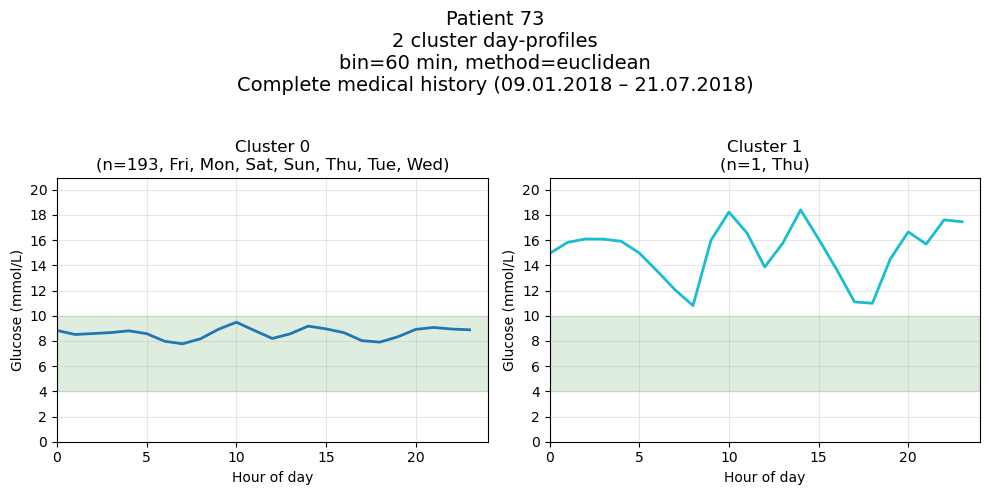

In [194]:
top1 = sorted(results_rolling.items(), key=lambda item: item[1]['score'], reverse=True)[:1]
plot_patient_cluster_rollingmean_complete(top1, patient_id)

#### With a given time range

In [197]:
# with a given time range
def plot_patient_cluster_rollingmean_timerange(best_result, PtID):
    """
    Plots each cluster of a chosen clustering result in its own subplot.

    Features:
    - Each cluster in its own subplot
    - Fixed y-axis across all subplots
    - Y-ticks every 2 mmol/L
    - X-axis fixed 0-24 h
    - Highlight TIR (4–10 mmol/L) as a light green band
    - Abbreviated weekday names in titles

    Parameters:
        best_result : tuple
            (key, value) from results dict, where:
               key = (bin_m, method, k)
               value contains: labels, X_filled, weekdays
        PtID : int or str
    """
    key, value = best_result
    bin_m, method, k = key

    labels = value['labels']
    X_data = value['X_filled'].values
    weekdays = value['weekdays']
    n_bins = X_data.shape[1]

    # Weekday names (abbreviated)
    weekday_names = [calendar.day_abbr[d.weekday()] for d in weekdays.index]

    # Cluster info
    cluster_sizes = {c: np.sum(labels == c) for c in range(k)}
    cluster_weekdays = {
        c: ", ".join(sorted(set([weekday_names[i] for i, lab in enumerate(labels) if lab == c])))
        for c in range(k)
    }

    # Print summary
    print(f"{i}. bin={bin_m}, method={method}, k={k}, silhouette={value['score']:.3f}")
    for c in range(k):
        print(f"  Cluster {c}: {cluster_sizes[c]} days ({cluster_weekdays[c]})")

    # Y-axis limits and ticks
    y_max = X_data.max() + 0.5
    y_ticks = np.arange(np.floor(0), np.ceil(y_max)+1, 2)  # every 2 mmol/L

    # Subplot layout
    if k <= 3:
        rows, cols = 1, k
    elif k == 4:
        rows, cols = 2, 2
    elif k <= 6:
        rows, cols = 2, 3
    else:
        rows, cols = 3, 3

    # Create figure (taller panels)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), squeeze=False)
    axes = axes.flatten()

    # Colors
    colors = plt.cm.tab10(np.linspace(0, 1, k))
    time_axis = np.arange(n_bins)*(bin_m/60)

    for c in range(k):
        ax = axes[c]
        mean_profile = X_data[labels == c].mean(axis=0)

        # Highlight TIR (4–10 mmol/L)
        ax.axhspan(4, 10, color='forestgreen', alpha=0.15)

        ax.plot(time_axis, mean_profile, lw=2, color=colors[c])
        ax.set_title(f"Cluster {c}\n(n={cluster_sizes[c]})\n{cluster_weekdays[c]}")
        ax.set_xlabel("Hour of day")
        ax.set_ylabel("Glucose (mmol/L)")
        ax.set_ylim(0, y_max)   # fixed y-axis
        ax.set_yticks(y_ticks)      # ticks every 2 mmol/L
        ax.set_xlim(0, 24)          # fixed x-axis 0–24 h
        ax.grid(alpha=0.3)

    # Remove empty subplots
    for j in range(k, len(axes)):
        fig.delaxes(axes[j])

    # Format date range for title if available
    start_date = weekdays.index.min()
    end_date = weekdays.index.max()
    start_str = pd.to_datetime(start_date).strftime("%d.%m.%Y")
    end_str = pd.to_datetime(end_date).strftime("%d.%m.%Y")
    if start_str == end_str:
        date_text = f"{start_str}"
    else:
        date_text = f"{start_str} – {end_str}"
    
    # Super title
    fig.suptitle(
        f"Patient {PtID}\n{k} cluster day-profiles\n"
        f"bin={bin_m} min, method={method}\nDate range: {date_text}",
        fontsize=14
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    fname = f"patient_cluster_typical_week.png"

    fig.savefig(
        fname,
        dpi=500,
        bbox_inches="tight",
        facecolor="white"
    )
    plt.show()

In [198]:
print(patient_date_range(73))

('2018-01-09', '2018-07-21')


In [199]:
patient_id = 73

start_date = pd.to_datetime('2018-04-01')
end_date   = pd.to_datetime('2018-04-30')

start_date = start_date.normalize()   # 2018-05-17 00:00:00
end_date   = end_date.normalize()

subset = dclp3[
    (dclp3['PtID'] == patient_id) &
    (dclp3['date'] >= start_date) &
    (dclp3['date'] <= end_date + pd.Timedelta(days=1) - pd.Timedelta(seconds=1))
].copy()

In [200]:
results_rolling_timerange = cluster_patient_days_experiment_rollingmean(subset)

5. bin=60, method=manhattan, k=2, silhouette=0.355
  Cluster 0: 27 days (Fri, Mon, Sat, Sun, Thu, Tue, Wed)
  Cluster 1: 3 days (Fri, Sat)


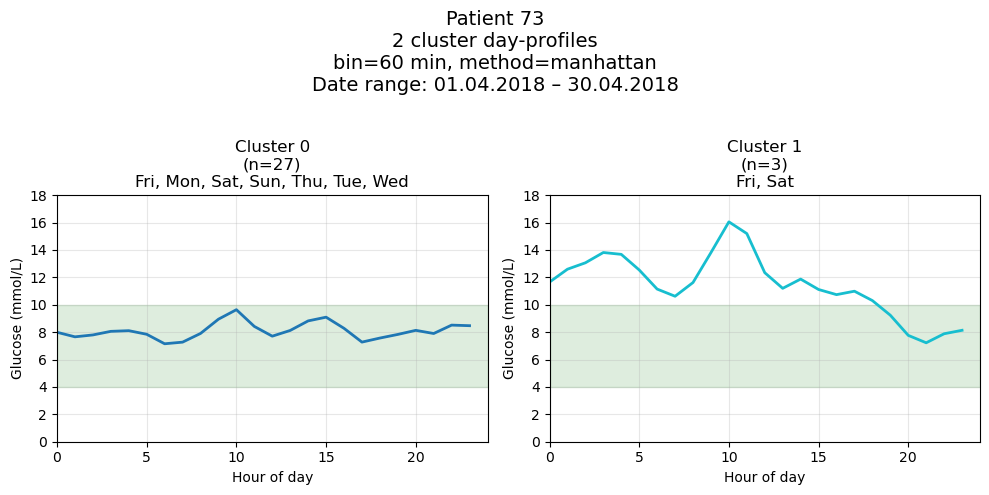

In [201]:
top1 = sorted(results_rolling_timerange.items(), key=lambda item: item[1]['score'], reverse=True)[:1]
plot_patient_cluster_rollingmean_timerange(top1[0], patient_id)

### Simply mmol (not that good)

In [202]:
def cluster_patient_days_experiment(df_patient, bin_sizes=[20,30,60], 
                                    methods=['euclidean','manhattan','corr','ward'], 
                                    cluster_counts=[2,3,4, 5, 6, 7]):
    
    results = {}
    
    # check that DataDtTm is datetime
    if not np.issubdtype(df_patient['DataDtTm'].dtype, np.datetime64):
        df_patient['DataDtTm'] = pd.to_datetime(df_patient['DataDtTm'])
    
    for bin_m in bin_sizes:
        df_binned, n_bins = prepare_bins(df_patient, bin_minutes=bin_m)
        
        # Pivot each day on a separate line
        daily_profiles_list = []
        day_index = []
        weekdays_list = []
        
        for day, g in df_binned.groupby('date'):
            g = g.set_index('DataDtTm')
            binned = g['CGM_mmol'].resample(f'{bin_m}min').mean().values
            daily_profiles_list.append(binned)
            day_index.append(day)
            weekdays_list.append(g['weekday_name'].iloc[0])
        
        daily_profiles = pd.DataFrame(daily_profiles_list)
        daily_profiles.index = day_index
        weekdays = pd.Series(weekdays_list, index=day_index)
        
        # Fill NaNs with average
        imputer = SimpleImputer(strategy='mean')
        X_filled = pd.DataFrame(imputer.fit_transform(daily_profiles),
                                index=daily_profiles.index,
                                columns=daily_profiles.columns)
        
        for method in methods:
            for k in cluster_counts:
                try:
                    X = X_filled.values
                    
                    if method == 'ward':
                        model = AgglomerativeClustering(n_clusters=k, linkage='ward')
                        labels = model.fit_predict(X)
                        score = silhouette_score(X, labels)
                    
                    elif method == 'corr':
                        dist = squareform(pdist(X, metric=lambda u,v: 1 - np.corrcoef(u,v)[0,1]))
                        model = AgglomerativeClustering(n_clusters=k, linkage='average', metric='precomputed')
                        labels = model.fit_predict(dist)
                        score = silhouette_score(dist, labels, metric='precomputed')
                    
                    else:  # euclidean or manhattan
                        model = AgglomerativeClustering(n_clusters=k, linkage='average', metric=method)
                        labels = model.fit_predict(X)
                        score = silhouette_score(X, labels, metric=method)
                        
                    key = (bin_m, method, k)
                    results[key] = {
                        'labels': labels,
                        'score': score,
                        'X_scaled': X,
                        'weekdays': weekdays
                    }
                except Exception as e:
                    print(f"Failed: bin={bin_m}, method={method}, k={k}: {e}")
    
    return results

In [208]:
def plot_top_patient_day_clusters(best_results, PtID):
    """
    Visualizes top patient-day clusterings using scaled glucose,
    with each cluster in its own subplot, fixed axes,
    TIR band (4–10 mmol/L), and abbreviated weekday names.
    
    Parameters:
        best_results: list of tuples
            [(key, value), ...] as returned by sorting results by silhouette.
            key = (bin_size, method, k)
            value = dict with keys: labels, score, X_scaled, weekdays (pd.Series indexed by day)
    """
    for i, (key, value) in enumerate(best_results, 1):
        bin_m, method, k = key
        labels = value['labels']
        X_data = value['X_scaled']
        weekdays = value['weekdays']
        n_bins = X_data.shape[1]

        # Abbreviated weekday names (Mon, Tue, ...)
        weekday_names = [calendar.day_abbr[d.weekday()] for d in weekdays.index]

        # Cluster info
        cluster_weekdays = {}
        cluster_sizes = {}
        for c in range(k):
            cluster_days = [weekday_names[idx] for idx, lab in enumerate(labels) if lab == c]
            cluster_weekdays[c] = ", ".join(sorted(set(cluster_days)))
            cluster_sizes[c] = np.sum(labels == c)

        # Print summary
        print(f"{i}. bin={bin_m}, method={method}, k={k}, silhouette={value['score']:.3f}")
        for c in range(k):
            print(f"  Cluster {c}: {cluster_sizes[c]} days ({cluster_weekdays[c]})")

        # Axes setup
        time_axis = np.arange(n_bins) * (bin_m / 60)
        y_max = X_data.max() + 0.5
        y_ticks = np.arange(np.floor(X_data.min()), np.ceil(y_max) + 1, 2)

        # Subplots (each cluster its own panel)
        cols = 2
        rows = math.ceil(k / cols)
        fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5), squeeze=False)
        axes = axes.flatten()

        colors = plt.cm.tab10(np.linspace(0, 1, k))

        for c in range(k):
            ax = axes[c]
            mean_profile = X_data[labels == c].mean(axis=0)

            # TIR band
            ax.axhspan(4, 10, color='forestgreen', alpha=0.15)

            ax.plot(time_axis, mean_profile, lw=2, color=colors[c])
            ax.set_title(f"Cluster {c}\n(n={cluster_sizes[c]}, {cluster_weekdays[c]})")
            ax.set_xlabel("Hour of day")
            ax.set_ylabel("Glucose (mmol/L)")
            ax.set_xlim(0, 24)
            ax.set_ylim(X_data.min() - 0.5, y_max)
            ax.set_yticks(y_ticks)
            ax.grid(alpha=0.3)

        # Remove empty panels
        for j in range(k, len(axes)):
            fig.delaxes(axes[j])

        fig.suptitle(
            f"Patient {PtID}\nDay clusters (scaled glucose)\n"
            f"bin={bin_m} min, method={method}, k={k}",
            fontsize=14
        )

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

In [204]:
patient_id = 167
df_patient = dclp3[dclp3['PtID']==patient_id]
results = cluster_patient_days_experiment(df_patient)

1. bin=30, method=manhattan, k=2, silhouette=0.374
  Cluster 0: 189 days (Fri, Mon, Sat, Sun, Thu, Tue, Wed)
  Cluster 1: 7 days (Fri, Sun, Tue, Wed)


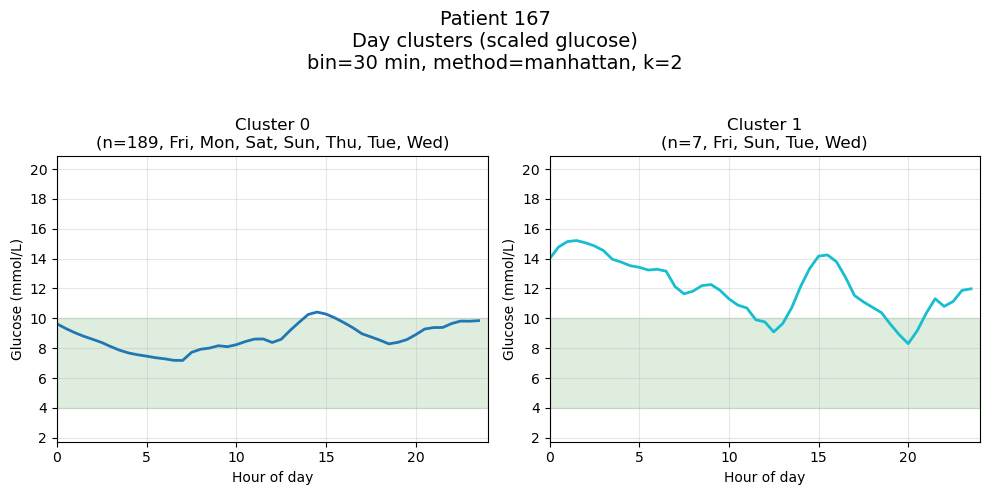

In [209]:
top1 = sorted(results.items(), key=lambda item: item[1]['score'], reverse=True)[:1]
plot_top_patient_day_clusters(top1, patient_id)